In [2]:
# Importing libraries

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
import os
import ipympl
import warnings
from astropy.utils.exceptions import AstropyUserWarning
from astropy import units as u
import pyneb as pn
from astropy.stats import median_absolute_deviation as mad
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.optimize import curve_fit
#from sklearn.linear_model import TheilSenRegressor

from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import root_scalar
import ipympl

# Making x and y ticks more readable
from matplotlib.ticker import MaxNLocator   

# for countourf 
import matplotlib.tri as tri

In [3]:
warnings.filterwarnings('ignore', category=AstropyUserWarning)

#base_dir = '/Users/amritasingh/amrita/LVM/LVM_lagoon_outputs/1.1.2dev0_outputs/'

base_dir = '/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/'
plot_dir = base_dir+f'paper_plots/'

In [4]:
################################## spatially resolved data ###################################

with fits.open(base_dir+f'resolved/lagoon_obs_corr_flux_table_1.1.2dev0_jul8.fits') as hdu:
    data = hdu[1].data
    header = hdu[1].header

RA_list = data['obs_RA']
Dec_list =  data['obs_Dec']


with fits.open(base_dir+f'resolved/lagoon_combined_multi_normalized_diagnostics_1.1.2dev0.fits') as hdu:
    diag = hdu[1].data
    header = hdu[1].header

################################## radially binned data ###################################
filename =  base_dir+f'annbinned/annular_binned_obs_corr_flux_1.1.2dev0.fits'
with fits.open(filename) as hdul:
    binned = hdul[1].data
    header = hdul[1].header
    
with fits.open(base_dir+f'annbinned/multi_normalized_lagoon_anbinned_diagnostics_1.1.2dev0.fits') as  hdu:
    diag_binned = hdu[1].data
    header = hdu[1].header

################################### elliptical mask binned ##################################
with fits.open(base_dir+f'ellbinned/mean_multi_normalized_ellipse_masked_annbinned_obs_corr_flux_1.1.2dev0.fits') as hdu:
    header = hdu[1].header
    ell_binned = hdu[1].data


with fits.open(base_dir+f'ellbinned/mean_multi_normalized_ellipse_masked_annularbins_diagnostics_1.1.2dev0.fits') as hdu:
    ell_diag_binned = hdu[1].data
    header = hdu[1].header


############################################ integrated data ########################################

with fits.open(base_dir+f'integrated/multi_normalized_lagoon_integrated_obs_corr_flux_1.1.2dev0.fits') as hdul:
    int_data = hdul[1].data
    header = hdul[1].header
    #print(repr(header))

with fits.open(base_dir+f'integrated/multi_normalized_lagoon_integrated_diagnostics_table_1.1.2dev0.fits') as hdul:
    diag_int = hdul[1].data
    header = hdul[1].header


############################################ elliptical mask integrated data ########################################

with fits.open(base_dir+f'integrated/multi_normalized_lagoon_ellipse_integrated_obs_corr_flux_1.1.2dev0.fits') as hdul:
    ell_int_data = hdul[1].data
    header = hdul[1].header

with fits.open(base_dir+f'integrated/multi_normalized_lagoon_ellipse_integrated_diagnostics_table_1.1.2dev0.fits') as hdul:
    ell_diag_int = hdul[1].data
    header = hdul[1].header

#print(repr(header))

############################################ central spaxel data ########################################

with fits.open(base_dir+f'integrated/multi_normalized_lagoon_central_spaxel_obs_corr_flux_1.1.2dev0.fits') as hdul:
    central_spaxel_data = hdul[1].data
    header = hdul[1].header

with fits.open(base_dir+f'integrated/multi_normalized_lagoon_central_spaxel_diagnostics_table_1.1.2dev0.fits') as hdul:
    central_spaxel_diag = hdul[1].data
    header = hdul[1].header


############################################ TeORL #############################################

hdu =  fits.open(base_dir+f'resolved/lagoon_combined_multi_normalized_TeOrl_from_ratio_and_ne_1.1.2dev0.fits')
datal =  hdu[1].data
te_obs = datal['Te_obs']
te_obs_err = datal['Te_obs_err']
ratio_obs =  datal['Ratio_obs']
ratio_err =  datal['Ratio_err']



with fits.open(base_dir+f'annbinned/multi_normalized_lagoon_anbinned_TeOrl_1.1.2dev0.fits') as hdu:
 
    bins = hdu[1].data

    te_obs_binned =    bins['Te_obs']
    te_obs_err_binned =bins['Te_obs_err']
    ratio_obs_binned = bins['Ratio_obs']
    ratio_err_binned = bins['Ratio_err']

with fits.open(base_dir+f'ellbinned/mean_multi_normalized_lagoon_elliptical_mask_TeOrl_from_ratio_and_ne.fits') as hdu:

    ell_bins = hdu[1].data
    ell_te_obs_binned =    ell_bins['Te_obs']
    ell_te_obs_err_binned =ell_bins['Te_obs_err']
    ell_ratio_obs_binned = ell_bins['Ratio_obs']
    ell_ratio_err_binned = ell_bins['Ratio_err']

with fits.open(base_dir+f'integrated/multi_normalized_ellipse_integrated_TeOrl_1.1.2dev0.fits') as hdu:
    
    ell_int = hdu[1].data
    ell_te_obs_int =    ell_int['Te_obs']
    ell_te_obs_err_int =ell_int['Te_obs_err']
    ell_ratio_obs_int = ell_int['Ratio_obs']
    ell_ratio_err_int = ell_int['Ratio_err']

with fits.open(base_dir+f'integrated/multi_normalized_integrated_TeOrl_1.1.2dev0.fits') as hdu:
    int = hdu[1].data

    te_obs_int =    int['Te_obs']
    te_obs_err_int =int['Te_obs_err']
    ratio_obs_int = int['Ratio_obs']
    ratio_err_int = int['Ratio_err']

with fits.open(base_dir+f'integrated/multi_normalized_central_spaxel_TeOrl_1.1.2dev0.fits') as hdu:
    central_spaxel = hdu[1].data

    te_obs_central_spaxel =    central_spaxel['Te_obs']
    te_obs_err_central_spaxel =central_spaxel['Te_obs_err']
    ratio_obs_central_spaxel = central_spaxel['Ratio_obs']
    ratio_err_central_spaxel = central_spaxel['Ratio_err']  

In [5]:
#################### calculating distances in parsecs annd arcmins ###########################

RA = data['obs_RA']
Dec = data['obs_dec']

#Assuming Her 36 binary as center for RA and Dec coordinates
ra_hms = '18 03 40.3201232304'
dec_dms = '-24 22 42.857540472'

coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

# Converting RA and Dec to degrees using Skycoord
ra_center_deg = coord.ra.deg
dec_center_deg = coord.dec.deg
distance_to_nebula = 1250  # in parsecs

# Calculatinf the angular distance in degrees and also adjusting RA by the cosine of the declination
angular_distances_deg = np.sqrt(
    ((RA - ra_center_deg) * np.cos(np.radians(dec_center_deg)))**2 +
    (Dec - dec_center_deg)**2)

# Angular distance from degrees to parsecs
# Degrees to radians: radians = degrees * (np.pi / 180). Then, distance in parsecs = distance_to_nebula * angular_distance_in_radians
angular_distances_rad = angular_distances_deg * (np.pi / 180)
distances_parsec = distance_to_nebula * angular_distances_rad

# Converting angular distances from degrees to arcminutes
angular_distances_arcmin = angular_distances_deg * 60

distance_bin = binned['obs_distance']

# highlight spaxels at the center (up to 2 decimal places) closer  to the coord of Her36
her36_sapxel = (np.round(RA, 2) == np.round(ra_center_deg, 2)) & (np.round(Dec, 2) == np.round(dec_center_deg, 2))

ra_ref, dec_ref = 270.92372608, -24.37629402 # highest desity, 270.91774318, -24.3641394, determined as brightest spaxel for 5007 SB
close_mask = np.isclose(RA, ra_ref, atol=1e-3) & np.isclose(Dec, dec_ref, atol=1e-3)
highlight = np.where(close_mask)

#print(angular_distances_arcmin[highlight][1], flux[highlight][1])
print('central spaxel of brightest spaxel:', RA[highlight], Dec[highlight], ra_ref, dec_ref)
print('her 36 spaxel:', RA[her36_sapxel], Dec[her36_sapxel])

# coordinates of brightest spaxel in 5007 line : [270.91774318] [-24.3641394]

central spaxel of brightest spaxel: [] [] 270.92372608 -24.37629402
her 36 spaxel: [] []


In [10]:
########################### some important measurements ################################
RA_list = data['obs_RA']
Dec_list =  data['obs_Dec']
dr = 1
r_bin = diag_binned['distance']


# spatially resolved
oii_sum =data['int_NII_OII_flux3']+data['int_NII_OII_flux4']+data['int_NII_OII_flux5']+data['int_NII_OII_flux6']+data['int_NII_OII_flux8']+data['int_NII_OII_flux9'] #-1.37*data['int_NII_OII_flux1']

oii_sum_err =np.sqrt(data['int_NII_OII_flux3_err']**2+data['int_NII_OII_flux4_err']**2+data['int_NII_OII_flux5_err']**2+
                     data['int_NII_OII_flux6_err']**2+data['int_NII_OII_flux8_err']**2+data['int_NII_OII_flux9_err']**2) #-1.37*data['int_NII_OII_flux1']

oiii_5007 =data['int_[OIII]5007_flux0']
oiii_4363 =data['int_[OIII]4363_flux1']
oiii_4363_err =data['int_[OIII]4363_flux1_err']

hb =data['int_Hb4861_flux0']

snr_orl = (data['int_NII_OII_flux5']+data['int_NII_OII_flux6'])/np.sqrt(data['int_NII_OII_flux5_err']**2+data['int_NII_OII_flux6_err']**2)
snr_cel = data['int_[OIII]4363_flux1']/data['int_[OIII]4363_flux1_err']

# annular binned
oii_sum_binned = binned['int_NII_OII_flux3']+binned['int_NII_OII_flux4']+binned['int_NII_OII_flux5']+binned['int_NII_OII_flux6']+binned['int_NII_OII_flux8']+binned['int_NII_OII_flux9']#-1.37*binned['int_NII_OII_flux1']

oii_sum_binned_err = np.sqrt(binned['int_NII_OII_flux3_err']**2+binned['int_NII_OII_flux4_err']**2+binned['int_NII_OII_flux5_err']**2+
                         binned['int_NII_OII_flux6_err']**2+binned['int_NII_OII_flux8_err']**2+binned['int_NII_OII_flux9_err']**2)#-1.37*binned['int_NII_OII_flux1']

oiii_5007_binned = binned['int_[OIII]5007_flux0']
oiii_4363_binned = binned['int_[OIII]4363_flux1']
oiii_4363_binned_err = binned['int_[OIII]4363_flux1_err']

hb_binned = binned['int_Hb4861_flux0']

snr_orl_binned = binned['int_NII_OII_flux5']+binned['int_NII_OII_flux6']/np.sqrt(binned['int_NII_OII_flux5_err']**2+binned['int_NII_OII_flux6_err']**2)
snr_cel_binned = binned['int_[OIII]4363_flux1']/binned['int_[OIII]4363_flux1_err']

# elliptical annular binned
ell_oii_sum_binned = ell_binned['int_NII_OII_flux3']+ell_binned['int_NII_OII_flux4']+ell_binned['int_NII_OII_flux5']+\
ell_binned['int_NII_OII_flux6']+ell_binned['int_NII_OII_flux8']+ell_binned['int_NII_OII_flux9']#-1.37*binned['int_NII_OII_flux1']

ell_oii_sum_binned_err = np.sqrt(ell_binned['int_NII_OII_flux3_err']**2+ell_binned['int_NII_OII_flux4_err']**2+ell_binned['int_NII_OII_flux5_err']**2+\
                         ell_binned['int_NII_OII_flux6_err']**2+ell_binned['int_NII_OII_flux8_err']**2+ell_binned['int_NII_OII_flux9_err']**2)#-1.37*binned['int_NII_OII_flux1']

oiii_5007_binned = ell_binned['int_[OIII]5007_flux0']
oiii_4363_binned = ell_binned['int_[OIII]4363_flux1']
oiii_4363_binned_err = ell_binned['int_[OIII]4363_flux1_err']

hb_binned = ell_binned['int_Hb4861_flux0']

ell_snr_orl_binned = ell_binned['int_NII_OII_flux5']+ell_binned['int_NII_OII_flux6']/np.sqrt(ell_binned['int_NII_OII_flux5_err']**2+ell_binned['int_NII_OII_flux6_err']**2)
ell_snr_cel_binned = ell_binned['int_[OIII]4363_flux1']/ell_binned['int_[OIII]4363_flux1_err']

# integrated data
oii_sum_int = int_data['int_NII_OII_flux3']+int_data['int_NII_OII_flux4']+int_data['int_NII_OII_flux5']+int_data['int_NII_OII_flux6']+int_data['int_NII_OII_flux8']+int_data['int_NII_OII_flux9']#-1.37*int_data['int_NII_OII_flux1']
oiii_5007_int = int_data['int_[OIII]5007_flux0']
oiii_4363_int = int_data['int_[OIII]4363_flux1']
hb_int = int_data['int_Hb4861_flux0']

oii_sum_int_err = np.sqrt(int_data['int_NII_OII_flux3_err']**2+int_data['int_NII_OII_flux4_err']**2+int_data['int_NII_OII_flux5_err']**2+
                          int_data['int_NII_OII_flux6_err']**2+int_data['int_NII_OII_flux8_err']**2+int_data['int_NII_OII_flux9_err']**2)#-1.37*int_data['int_NII_OII_flux1']

oiii_5007_int_err = int_data['int_[OIII]5007_flux0_err']
oiii_4363_int_err = int_data['int_[OIII]4363_flux1_err']
hb_int_err = int_data['int_Hb4861_flux0_err']

snr_orl_int = int_data['int_NII_OII_flux5']+int_data['int_NII_OII_flux6']/np.sqrt(int_data['int_NII_OII_flux5_err']**2+int_data['int_NII_OII_flux6_err']**2)
snr_cel_int = int_data['int_[OIII]4363_flux1']/int_data['int_[OIII]4363_flux1_err']

######################################################## elliptical integrated data  #######################################################
ell_oii_sum_int = ell_int_data['int_NII_OII_flux3']+ell_int_data['int_NII_OII_flux4']+ell_int_data['int_NII_OII_flux5']+\
ell_int_data['int_NII_OII_flux6']+ell_int_data['int_NII_OII_flux8']+ell_int_data['int_NII_OII_flux9']#-1.37*int_data['int_NII_OII_flux1']

ell_oiii_5007_int = ell_int_data['int_[OIII]5007_flux0']
ell_oiii_4363_int = ell_int_data['int_[OIII]4363_flux1']
ell_hb_int = ell_int_data['int_Hb4861_flux0']

ell_oii_sum_int_err = np.sqrt(ell_int_data['int_NII_OII_flux3_err']**2+ell_int_data['int_NII_OII_flux4_err']**2+ell_int_data['int_NII_OII_flux5_err']**2+
                          ell_int_data['int_NII_OII_flux6_err']**2+ell_int_data['int_NII_OII_flux8_err']**2+ell_int_data['int_NII_OII_flux9_err']**2)#-1.37*int_data['int_NII_OII_flux1']

ell_oiii_5007_int_err = ell_int_data['int_[OIII]5007_flux0_err']
ell_oiii_4363_int_err = ell_int_data['int_[OIII]4363_flux1_err']
ell_hb_int_err = ell_int_data['int_Hb4861_flux0_err']

ell_snr_orl_int = ell_int_data['int_NII_OII_flux5']+ell_int_data['int_NII_OII_flux6']/np.sqrt(ell_int_data['int_NII_OII_flux5_err']**2+ell_int_data['int_NII_OII_flux6_err']**2)
ell_snr_cel_int = ell_int_data['int_[OIII]4363_flux1']/ell_int_data['int_[OIII]4363_flux1_err']

######################################################## central spaxel data #######################################################
central_spaxel_oii_sum = central_spaxel_data['int_NII_OII_flux3']+central_spaxel_data['int_NII_OII_flux4']+central_spaxel_data['int_NII_OII_flux5']+\
central_spaxel_data['int_NII_OII_flux6']+central_spaxel_data['int_NII_OII_flux8']+central_spaxel_data['int_NII_OII_flux9']#-1.37*central_spaxel_data['int_NII_OII_flux1']

central_spaxel_oii_sum_err = np.sqrt(central_spaxel_data['int_NII_OII_flux3_err']**2+central_spaxel_data['int_NII_OII_flux4_err']**2+ 
                            central_spaxel_data['int_NII_OII_flux5_err']**2+central_spaxel_data['int_NII_OII_flux6_err']**2+
                            central_spaxel_data['int_NII_OII_flux8_err']**2+central_spaxel_data['int_NII_OII_flux9_err']**2)#-1.37*central_spaxel_data['int_NII_OII_flux1']

central_spaxel_oiii_5007 = central_spaxel_data['int_[OIII]5007_flux0']
central_spaxel_oiii_4363 = central_spaxel_data['int_[OIII]4363_flux1']
central_spaxel_hb = central_spaxel_data['int_Hb4861_flux0']
central_spaxel_oiii_5007_err = central_spaxel_data['int_[OIII]5007_flux0_err']
central_spaxel_oiii_4363_err = central_spaxel_data['int_[OIII]4363_flux1_err']
central_spaxel_hb_err = central_spaxel_data['int_Hb4861_flux0_err']

central_spaxel_snr_orl =  (central_spaxel_data['int_NII_OII_flux5']+central_spaxel_data['int_NII_OII_flux6'])/np.sqrt(central_spaxel_data['int_NII_OII_flux5_err']**2+central_spaxel_data['int_NII_OII_flux6_err']**2)
central_spaxel_snr_cel = central_spaxel_data['int_[OIII]4363_flux1']/central_spaxel_data['int_[OIII]4363_flux1_err']

####################################################### distances #####################################################
r_bin = binned['obs_distance']
ell_r_bin = ell_binned['obs_distance']

####################### compile useful terms ##################### 

teo3cel = diag['TeO3']
teo3rl = te_obs
teo3celerr = diag['TeO3err']
teo3rlerr = te_obs_err
del_te = teo3cel-teo3rl
del_te_err = np.sqrt(teo3celerr**2 + teo3rlerr**2)
nes2 = diag['neS2']
nes2err = diag['neS2err']

# annular binned FOV
teo3cel_bin = diag_binned['TeO3']
teo3rl_bin = te_obs_binned
teo3celerr_bin = diag_binned['TeO3err']
teo3rlerr_bin = te_obs_err_binned
del_te_bin = teo3cel_bin-teo3rl_bin
del_te_err_bin = np.sqrt(teo3celerr_bin**2 + teo3rlerr_bin**2)
nes2_bin = diag_binned['neS2']
nes2err_bin = diag_binned['neS2err']

#intgrated
teo3cel_int = diag_int['TeO3']
teo3rl_int = te_obs_int
teo3celerr_int = diag_int['TeO3err']
teo3rlerr_int = te_obs_err_int
del_te_int = teo3cel_int-teo3rl_int
del_te_err_int = np.sqrt(teo3celerr_int**2 + teo3rlerr_int**2)
nes2_int = diag_int['neS2']
nes2err_int = diag_int['neS2err']

# elliptical mask binned

ell_teo3cel_bin = ell_diag_binned['TeO3']
ell_teo3rl_bin = ell_te_obs_binned
ell_teo3celerr_bin = ell_diag_binned['TeO3err']
ell_teo3rlerr_bin = ell_te_obs_err_binned
ell_del_te_bin = ell_teo3cel_bin-ell_teo3rl_bin
ell_del_te_err_bin = np.sqrt(ell_teo3celerr_bin**2 + ell_teo3rlerr_bin**2)
ell_nes2_bin = ell_diag_binned['neS2']
ell_nes2err_bin = ell_diag_binned['neS2err']

# elliptical mask integrated    
ell_teo3cel_int = ell_diag_int['TeO3']
ell_teo3rl_int = te_obs_int
ell_teo3celerr_int = ell_diag_int['TeO3err']
ell_teo3rlerr_int = te_obs_err_int
ell_del_te_int = teo3cel_int-teo3rl_int
ell_del_te_err_int = np.sqrt(teo3celerr_int**2 + teo3rlerr_int**2)
ell_nes2_int = ell_diag_int['neS2']
ell_nes2err_int = ell_diag_int['neS2err']

# central spaxel
central_spaxel_teo3cel = central_spaxel_diag['TeO3']
central_spaxel_teo3rl = te_obs_central_spaxel
central_spaxel_teo3celerr = central_spaxel_diag['TeO3err']
central_spaxel_teo3rlerr = te_obs_err_central_spaxel 
central_spaxel_del_te = central_spaxel_teo3cel-central_spaxel_teo3rl
central_spaxel_del_te_err = np.sqrt(central_spaxel_teo3celerr**2 + central_spaxel_teo3rlerr**2)

####################################### elemental abundance of O ############################
def elemental_abund_O(resolved_opp, resolved_opp_err, binned_opp, binned_opp_err, ell_binned_opp, ell_binned_opp_err, resolved_op, resolved_op_err, binned_op, 
                      binned_op_err, ell_binned_op, ell_binned_op_err, int_opp, int_op, ell_int_opp, ell_int_op, central_spaxel_opp, central_spaxel_op, central_spaxel_opp_err, central_spaxel_op_err):
    
    elemental_abund_o = 12 + np.log10(10 ** (resolved_opp - 12) + 10 ** (resolved_op - 12))
    elemental_abund_o_err = np.sqrt(resolved_opp_err**2 + resolved_op_err**2)

    bin_elemental_abund_o = 12 + np.log10(10 ** (binned_opp - 12) + 10 ** (binned_op - 12))
    bin_elemental_abund_o_err = np.sqrt(binned_opp_err**2 + binned_op_err**2)

    ell_bin_elemental_abund_o  = 12 + np.log10(10 ** (ell_binned_opp - 12) + 10 ** (ell_binned_op - 12))
    ell_bin_elemental_abund_o_err = np.sqrt(ell_binned_opp_err**2 + ell_binned_op_err**2)

    int_elemental_abund_o = 12 + np.log10(10 ** (int_opp - 12) + 10 ** (int_op - 12))
    ell_int_elemental_abund_o = 12 + np.log10(10 ** (ell_int_opp - 12) + 10 ** (ell_int_op - 12))

    central_spaxel_elemental_abund_o = 12 + np.log10(10 ** (central_spaxel_opp - 12) + 10 ** (central_spaxel_op - 12))
    central_spaxel_elemental_abund_o_err = np.sqrt(central_spaxel_opp_err**2 + central_spaxel_op_err**2)

    return elemental_abund_o, elemental_abund_o_err, ell_bin_elemental_abund_o, ell_bin_elemental_abund_o_err, \
bin_elemental_abund_o, bin_elemental_abund_o_err, int_elemental_abund_o, ell_int_elemental_abund_o, central_spaxel_elemental_abund_o, central_spaxel_elemental_abund_o_err

ocel, ocelerr, ellocelbin, ellocelbinerr, ocelbin, ocelbinerr, ocelint, ellocelint, cenocel, cenocelerr = elemental_abund_O(diag['Opp_cel'], diag['Opp_cel_err'], diag_binned['Opp_cel'], diag_binned['Opp_cel_err'], 
                  ell_diag_binned['Opp_cel'], ell_diag_binned['Opp_cel_err'], diag['Op_cel'], diag['Op_cel_err'], diag_binned['Op_cel'], 
                  diag_binned['Op_cel_err'], ell_diag_binned['Op_cel'], ell_diag_binned['Op_cel_err'],  diag_int['Opp_cel'], diag_int['Op_cel'], 
                  ell_diag_int['Opp_cel'], ell_diag_int['Op_cel'], central_spaxel_diag['Opp_cel'], central_spaxel_diag['Op_cel'], central_spaxel_diag['Opp_cel_err'], central_spaxel_diag['Op_cel_err'])

orl, orlerr, ellorlbin, ellorlbinerr, orlbin, orlbinerr, orlint, ellorlint, cenorl, cenorlerr = elemental_abund_O(diag['Opp_RL'], diag['Opp_RL_err'], diag_binned['Opp_RL'], diag_binned['Opp_RL_err'], 
                  ell_diag_binned['Opp_RL'], ell_diag_binned['Opp_RL_err'], diag['Op_cel'], diag['Op_cel_err'], diag_binned['Op_cel'], 
                  diag_binned['Op_cel_err'], ell_diag_binned['Op_cel'], ell_diag_binned['Op_cel_err'],  diag_int['Opp_RL'], diag_int['Op_cel'], 
                  ell_diag_int['Opp_RL'], ell_diag_int['Op_cel'], central_spaxel_diag['Opp_RL'], central_spaxel_diag['Op_cel'], central_spaxel_diag['Opp_RL_err'], central_spaxel_diag['Op_cel_err'])

def calculate_adf(Opp_cel, Opp_rl, Opp_cel_err, Opp_rl_err):
 
    Opp_RL_abund_linear = 10**(Opp_rl - 12) 
    Opp_cel_linear = 10**(Opp_cel - 12)

    # errors to linear scale
    Opp_RL_abund_linear_err = Opp_RL_abund_linear * np.log(10) * Opp_rl_err
    Opp_cel_linear_err = Opp_cel_linear * np.log(10) * Opp_cel_err

    # ADF in linear scale
    ADF_linear = Opp_RL_abund_linear / Opp_cel_linear

    # error on ADF in linear scale
    ADF_linear_err = ADF_linear * np.sqrt((Opp_RL_abund_linear_err / Opp_RL_abund_linear)**2 + 
                                          (Opp_cel_linear_err / Opp_cel_linear)**2)
 
    # ADF and its error back to logarithmic scale
    dex = np.log10(ADF_linear)
    err_dex = ADF_linear_err / (ADF_linear * np.log(10))

    return dex, err_dex


res_adf, res_adf_err = calculate_adf(diag['Opp_cel'], diag['Opp_RL'], diag['Opp_cel_err'], diag['Opp_RL_err'])
adf_bin, adf_err_bin = calculate_adf(diag_binned['Opp_cel'], diag_binned['Opp_RL'], diag_binned['Opp_cel_err'], diag_binned['Opp_RL_err'])
adf_int, adf_err_int = calculate_adf(diag_int['Opp_cel'], diag_int['Opp_RL'], diag_int['Opp_cel_err'], diag_int['Opp_RL_err'])
ell_adf_bin, ell_adf_err_bin = calculate_adf(ell_diag_binned['Opp_cel'], ell_diag_binned['Opp_RL'], ell_diag_binned['Opp_cel_err'], ell_diag_binned['Opp_RL_err'])
ell_adf_int, ell_adf_err_int = calculate_adf(ell_diag_int['Opp_cel'], ell_diag_int['Opp_RL'], ell_diag_int['Opp_cel_err'], ell_diag_int['Opp_RL_err'])

central_spaxel_adf, central_spaxel_adf_err = calculate_adf(central_spaxel_diag['Opp_cel'], central_spaxel_diag['Opp_RL'], central_spaxel_diag['Opp_cel_err'], central_spaxel_diag['Opp_RL_err'])

In [9]:
# Define PyNeb atoms
O2r = pn.RecAtom('O', 2)
O3 = pn.Atom('O', 3)
H1 = pn.RecAtom('H', 1)

In [15]:
#========================================= Script to calculate te =========================================#


In [7]:
################################## spatially resolved data ###################################


with fits.open(base_dir+f'resolved/lagoon_obs_corr_flux_table_1.1.2dev0_jul8.fits') as hdu:
    table = hdu[1].data
    header = hdu[1].header

print(repr(header))

with fits.open(base_dir+f'resolved/lagoon_combined_multi_normalized_diagnostics_1.1.2dev0.fits') as hdu:
    diag = hdu[1].data
    header = hdu[1].header

# Flux values and errors
f4638, f4638_err = table['int_NII_OII_flux3'], table['int_NII_OII_flux3_err']
f4641, f4641_err = table['int_NII_OII_flux4'], table['int_NII_OII_flux4_err']
f4649, f4649_err = table['int_NII_OII_flux5'], table['int_NII_OII_flux5_err']
f4650, f4650_err = table['int_NII_OII_flux6'], table['int_NII_OII_flux6_err']
f4662, f4662_err = table['int_NII_OII_flux8'], table['int_NII_OII_flux8_err']
f4676, f4676_err = table['int_NII_OII_flux9'], table['int_NII_OII_flux9_err']
f5007, f5007_err = table['int_[OIII]5007_flux0'], table['int_[OIII]5007_flux0_err']

# Sum of OII fluxes
sum_OII = f4638 + f4641 + f4649 + f4650 + f4662 + f4676

# Propagate error on sum
sum_OII_err = np.sqrt(f4638_err**2 + f4641_err**2 + f4649_err**2 + 
                      f4650_err**2 + f4662_err**2 + f4676_err**2)

# Compute ratio and propagate errors
ratio_obs = sum_OII / f5007
ratio_err = ratio_obs * np.sqrt((sum_OII_err / sum_OII)**2 + (f5007_err / f5007)**2)

# Print mean ratio and error
print(f"Mean ratio_obs: {np.nanmean(ratio_obs):.4f} ± {np.nanmean(ratio_err):.4f}")

ne_obs = diag['neS2']
ne_err = diag['neS2err']

# Define Te and ne grids
te_grid = np.linspace(3000, 20000, 30)
ne_grid = np.linspace(10, 2000, 20)

# Compute theoretical OII/[OIII] ratio grid
ratio_pyneb_grid = np.zeros((len(te_grid), len(ne_grid)))

for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        emis_OII = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl) 
                       for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23])
        emis_OIII = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        ratio_pyneb_grid[i, j] = emis_OII / emis_OIII

# Create 2D interpolation function
interp_func = RegularGridInterpolator((te_grid, ne_grid), ratio_pyneb_grid, 
                                      bounds_error=False, fill_value=None)

# Function to find Te for given (ratio, ne)
def find_te_for_ratio(ratio, ne):
    def func(te):  
        return interp_func((te, ne)) - ratio
    try:
        sol = root_scalar(func, bracket=[3000, 20000], method='brentq')
        return sol.root if sol.converged else np.nan
    except ValueError:
        return np.nan  

# Compute Te_obs
te_obs = np.array([find_te_for_ratio(r, n) for r, n in zip(ratio_obs, ne_obs)])

# **Monte Carlo Error Propagation**
n_MC = 50  # Number of MC iterations
te_obs_MC = np.zeros((len(ratio_obs), n_MC))

for i in range(n_MC):
    ratio_MC = np.random.normal(ratio_obs, ratio_err)  # Perturb ratio
    ne_MC = np.random.normal(ne_obs, ne_err)  # Perturb ne
    te_obs_MC[:, i] = np.array([find_te_for_ratio(r, n) for r, n in zip(ratio_MC, ne_MC)])

# Compute Te error as the standard deviation from MC trials
te_obs_err = np.nanstd(te_obs_MC, axis=1)

# Print results
print('Mean Te_obs:', np.nanmean(te_obs))
print('Median Te_obs:', np.nanmedian(te_obs))
print('Mean Te_err:', np.nanmean(te_obs_err))

cols = [
    fits.Column(name='Te_obs', format='E', array=te_obs),
    fits.Column(name='Te_obs_err', format='E', array=te_obs_err),
    fits.Column(name='Ratio_obs', format='E', array=ratio_obs),
    fits.Column(name='Ratio_err', format='E', array=ratio_err),
    fits.Column(name='ne_obs', format='E', array=ne_obs),
    fits.Column(name='ne_err', format='E', array=ne_err)
]

hdu = fits.BinTableHDU.from_columns(cols)
hdu.writeto(base_dir+f'resolved/lagoon_combined_multi_normalized_TeOrl_from_ratio_and_ne_1.1.2dev0.fits', overwrite=True)


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1296 / length of dimension 1                          
NAXIS2  =                17492 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                  162 / number of table fields                         
TTYPE1  = 'obs_RA  '                                                            
TFORM1  = 'D       '                                                            
TTYPE2  = 'obs_Dec '                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'obs_HI3750_flux0'

/Users/amritasingh/.local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Mean Te_obs: 5051.422529917314
Median Te_obs: 4935.428970275321
Mean Te_err: 620.377933807759


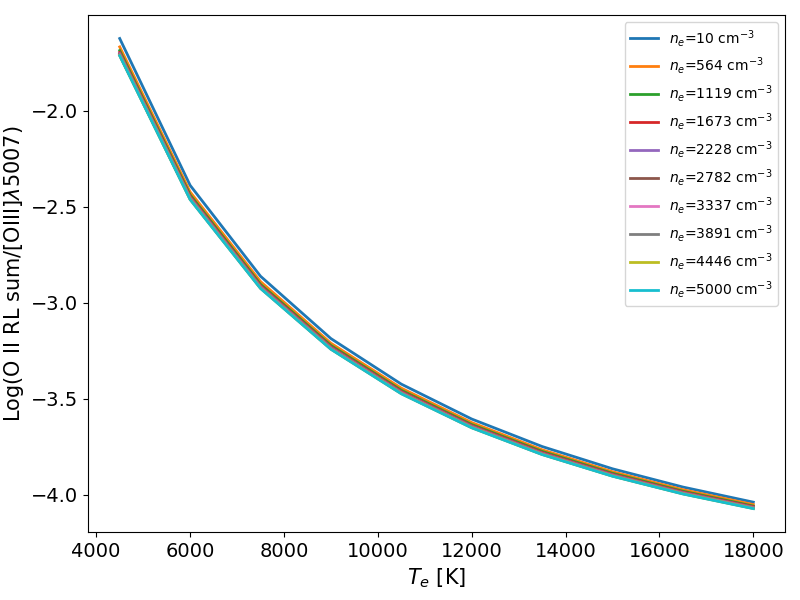

In [7]:
plt.figure(figsize=(8, 6))

# Define Te and ne grids
te_grid = np.linspace(4500, 18000, 10)
ne_grid = np.linspace(10, 5000, 10)

# Compute theoretical OII/[OIII] ratio grid
ratio_pyneb_grid = np.zeros((len(te_grid), len(ne_grid)))

for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        emis_OII = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl) 
                       for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23])
        emis_OIII = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        ratio_pyneb_grid[i, j] = emis_OII / emis_OIII

# Plot one curve per ne value
for j, ne in enumerate(ne_grid):
    plt.plot(te_grid, np.log10(ratio_pyneb_grid[:, j]), linestyle = '-', linewidth = 2, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')

plt.xlabel(r'$T_e$ [K]', fontsize = 15)
plt.ylabel(r'Log(O II RL sum/[OIII]$\lambda$5007)', fontsize = 15)
#plt.title(r'O II/[O III] vs $T_e$ for various $n_e$')
plt.legend(loc='upper right')
plt.tight_layout()
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
#plt.grid(True)
#plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/pyneb_plots/pyneb_OII_[OIII]_ratios_vs_Te_with_ne')

plt.show()


In [10]:
'''
plt.figure(figsize=(8, 6))

# Define Te and ne grids
te_grid = np.linspace(4500, 18000, 10)
ne_grid = np.linspace(10, 5000, 10)

# Compute theoretical OII/[OIII] ratio grid
ratio_pyneb_grid = np.zeros((len(te_grid), len(ne_grid)))

for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        emis_OIII_4363 = O3.getEmissivity(tem=te, den=ne, wave=4363)
        emis_OIII_5007 = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        ratio_pyneb_grid[i, j] = emis_OIII_4363 / emis_OIII_5007

# Plot one curve per ne value
for j, ne in enumerate(ne_grid):
    plt.plot(te_grid, np.log10(ratio_pyneb_grid[:, j]), linestyle = '-', linewidth = 2, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')

plt.xlabel(r'$T_e$ [K]', fontsize = 15)
plt.ylabel(r'Log([OIII]$\lambda$4363/[OIII]$\lambda$5007)', fontsize = 15)
#plt.title(r'O II/[O III] vs $T_e$ for various $n_e$')
plt.legend(loc='lower right')
plt.tight_layout()
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
#plt.grid(True)
plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/pyneb_plots/pyneb_[OIII]4363:5007_ratios_vs_Te_with_ne')

plt.show()
'''

"\nplt.figure(figsize=(8, 6))\n\n# Define Te and ne grids\nte_grid = np.linspace(4500, 18000, 10)\nne_grid = np.linspace(10, 5000, 10)\n\n# Compute theoretical OII/[OIII] ratio grid\nratio_pyneb_grid = np.zeros((len(te_grid), len(ne_grid)))\n\nfor i, te in enumerate(te_grid):\n    for j, ne in enumerate(ne_grid):\n        emis_OIII_4363 = O3.getEmissivity(tem=te, den=ne, wave=4363)\n        emis_OIII_5007 = O3.getEmissivity(tem=te, den=ne, wave=5006.84)\n        ratio_pyneb_grid[i, j] = emis_OIII_4363 / emis_OIII_5007\n\n# Plot one curve per ne value\nfor j, ne in enumerate(ne_grid):\n    plt.plot(te_grid, np.log10(ratio_pyneb_grid[:, j]), linestyle = '-', linewidth = 2, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')\n\nplt.xlabel(r'$T_e$ [K]', fontsize = 15)\nplt.ylabel(r'Log([OIII]$\\lambda$4363/[OIII]$\\lambda$5007)', fontsize = 15)\n#plt.title(r'O II/[O III] vs $T_e$ for various $n_e$')\nplt.legend(loc='lower right')\nplt.tight_layout()\nplt.xticks(fontsize = 14)\nplt.yticks(fontsize = 14)\n

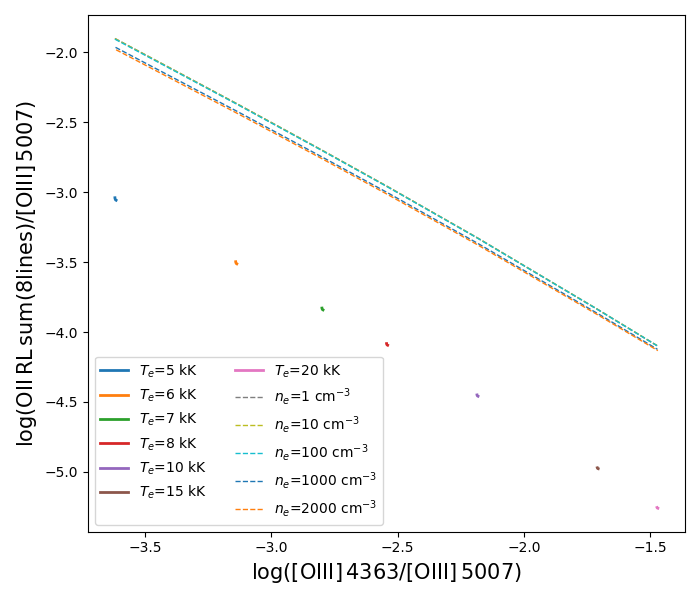

In [8]:
# Define Te and ne grids
te_grid = [5000, 6000, 7000, 8000, 10000, 15000, 20000]  
ne_grid = [1, 10, 100, 1000, 2000]     


ratio1_grid = np.zeros((len(te_grid), len(ne_grid)))  # OII RL sum / OIII 5007
ratio2_grid = np.zeros((len(te_grid), len(ne_grid)))  # OIII 4363 / 5007
ratio3_grid = np.zeros((len(te_grid), len(ne_grid)))  # OIII 4363 / 5007

# emissivity ratios
for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        emis_OII = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl)
                       for wl in [4638.86, 4641.81, 4649.13, 4650.84,
                                  4661.63, 4676.23, 4673.73, 4696.35])
        emis_5007 = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        emis_4363 = O3.getEmissivity(tem=te, den=ne, wave=4363)
        emis_hb = H1.getEmissivity(tem =te, den=ne, wave=4861)

        ratio1_grid[i, j] = emis_OII / emis_5007
        ratio2_grid[i, j] = emis_4363 / emis_5007
        ratio3_grid[i, j] = emis_hb / emis_5007


fig, ax = plt.subplots(figsize=(7,6))

# Plot Te curves 
for i, te in enumerate(te_grid):  
    x = np.log10(ratio2_grid[i, :])
    y = np.log10(ratio3_grid[i, :])
    ax.plot(x, y, '-', lw=2, label=f'$T_e$={te/1000:.0f} kK')

# Plot ne curves (dashed lines)
for j, ne in enumerate(ne_grid):
    x = np.log10(ratio2_grid[:, j])
    y = np.log10(ratio1_grid[:, j])
    ax.plot(x, y, '--', lw=1, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')

ax.set_ylabel(r'$\log(\mathrm{OII\,RL\,sum (8 lines)}/[\mathrm{OIII}]\,5007)$', fontsize=15)
ax.set_xlabel(r'$\log([\mathrm{OIII}]\,4363/[\mathrm{OIII}]\,5007)$', fontsize=15)

ax.legend(fontsize=10, loc='best', ncol=2)

plt.tight_layout()
plt.show()


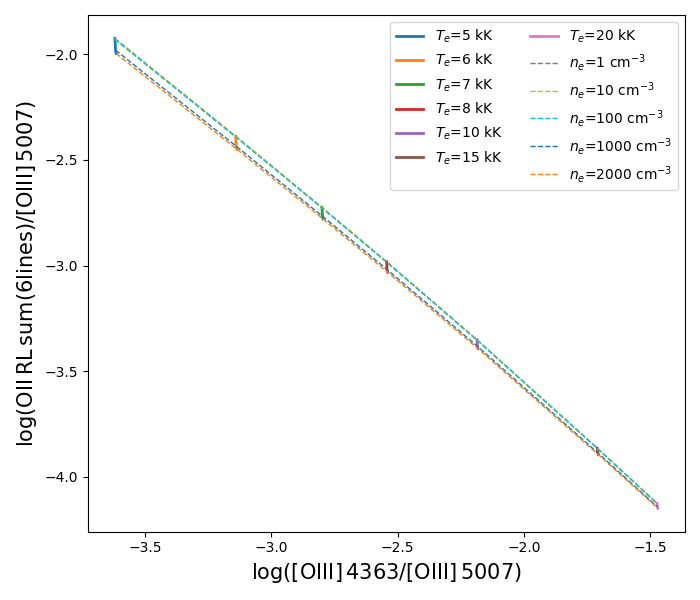

In [11]:

te_grid = [5000, 6000, 7000, 8000, 10000, 15000, 20000]   
ne_grid = [1, 10, 100, 1000, 2000]     

# Initialize arrays
ratio1_grid = np.zeros((len(te_grid), len(ne_grid)))  # OII RL sum / OIII 5007
ratio2_grid = np.zeros((len(te_grid), len(ne_grid)))  # OIII 4363 / 5007

# emissivity ratios
for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        emis_OII = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl)
                       for wl in [4638.86, 4641.81, 4649.13, 4650.84,
                                  4661.63, 4676.23])   #, 4673.73, 4696.35
        emis_5007 = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        emis_4363 = O3.getEmissivity(tem=te, den=ne, wave=4363)

        ratio1_grid[i, j] = emis_OII / emis_5007
        ratio2_grid[i, j] = emis_4363 / emis_5007


fig, ax = plt.subplots(figsize=(7,6))

# Plot Te curves 
for i, te in enumerate(te_grid):  
    x = np.log10(ratio2_grid[i, :])
    y = np.log10(ratio1_grid[i, :])
    ax.plot(x, y, '-', lw=2, label=f'$T_e$={te/1000:.0f} kK')

# Plot ne curves (dashed lines)
for j, ne in enumerate(ne_grid):
    x = np.log10(ratio2_grid[:, j])
    y = np.log10(ratio1_grid[:, j])
    ax.plot(x, y, '--', lw=1, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')

#ax.plot(oiii_4363_int / oiii_5007_int, oii_sum_int / oiii_5007_int, 'ro', alpha=0.1, label='M8 integrated measurement', markersize=5)
# Axis labels
ax.set_ylabel(r'$\log(\mathrm{OII\,RL\,sum(6 lines)}/[\mathrm{OIII}]\,5007)$', fontsize=15)
ax.set_xlabel(r'$\log([\mathrm{OIII}]\,4363/[\mathrm{OIII}]\,5007)$', fontsize=15)

ax.legend(fontsize=10, loc='best', ncol=2)

plt.tight_layout()
plt.show()


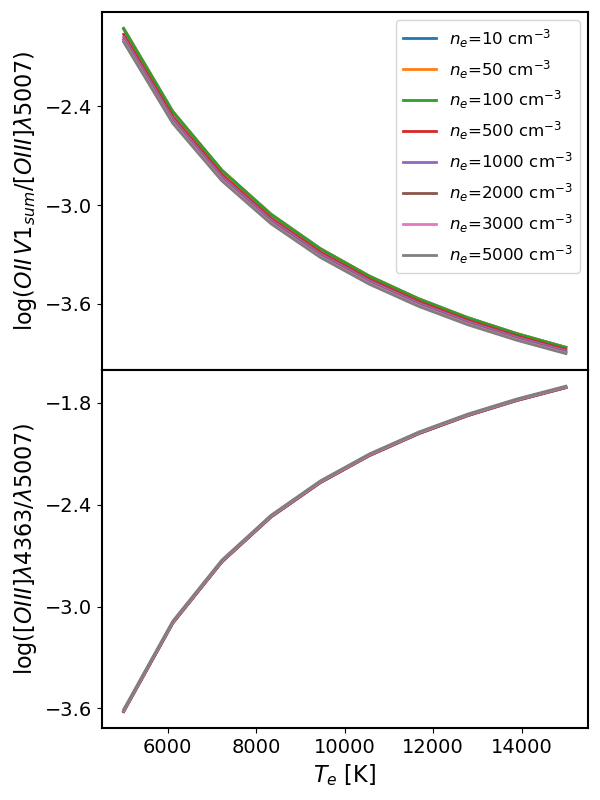

In [87]:

# Define Te and ne grids
te_grid = np.linspace(5000, 15000, 10)
ne_grid = [10, 50, 100, 500, 1000, 2000, 3000, 5000]

# Compute theoretical OII/[OIII] ratio grid
ratio1_grid = np.zeros((len(te_grid), len(ne_grid)))
ratio2_grid = np.zeros((len(te_grid), len(ne_grid)))

for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        
        emis_4363 = O3.getEmissivity(tem=te, den=ne, wave=4363)
        emis_OII = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl)
                       for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23]) #4638.86, , 4641.81, 4649.13, 4650.84, 4661.63, 4676.23, 4673.73, 4696.35
        emis_OIII = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        emis_hb = H1.getEmissivity(tem =te, den=ne, wave=4861)

        ratio1_grid[i, j] = emis_OII / emis_OIII
        ratio2_grid[i, j] = emis_hb / emis_OIII

# Compute [OIII] 4363 / 5007 ratio grid
ratio3_grid = np.zeros((len(te_grid), len(ne_grid)))
for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):
        emis_4363 = O3.getEmissivity(tem=te, den=ne, wave=4363)
        emis_5007 = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        ratio3_grid[i, j] = emis_4363 / emis_5007


# Create shared x-axis subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
        
#fig, (ax1) = plt.subplots(figsize=(8, 6)) #, sharex=True
#ax3  =ax1.twinx()

# --- First plot ---
for j, ne in enumerate(ne_grid):
    #ax3.plot(te_grid, np.log10(ratio2_grid[:, j]), linestyle='-', linewidth=2, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')
    ax1.plot(te_grid, np.log10(ratio1_grid[:, j]), linestyle='-', linewidth=2, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')
    
ax1.set_ylabel(r'$\log(OII\, V1_{sum}/[OIII]\lambda$5007)', fontsize=16)
#ax3.set_ylabel(r'$\log(H\beta/[\mathrm{OIII}]\lambda$5007)', fontsize=16)
ax1.set_ylim()
ax1.legend(loc='best', fontsize=12) #, title=r'$\log(OII\, RL\,4649+51/[OIII]\lambda$5007)'
#ax3.legend(loc='upper right', fontsize=10, title=r'$\log(H\beta/[\mathrm{OIII}]\,5007)$')
ax1.tick_params(axis='both', labelsize=14)
#ax3.tick_params(axis='both', labelsize=14)

# --- Second plot ---
for j, ne in enumerate(ne_grid):
    ax2.plot(te_grid, np.log10(ratio3_grid[:, j]), linestyle='-', linewidth=2, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')

ax2.set_xlabel(r'$T_e$ [K]', fontsize=16)
ax2.set_ylabel(r'$\log([OIII]\lambda$4363/$\lambda$5007)', fontsize=16)
#ax2.legend(loc='lower right', fontsize=10)
ax2.tick_params(axis='both', labelsize=14)
ax2.yaxis.set_major_locator(MaxNLocator(nbins=4))

ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))
#ax3.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=4))

plt.rcParams['axes.linewidth'] = 1.5

plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.savefig('/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/paper_plots/oiisum_and_4363_vs_5007_ratios_vs_te_for_ne.png')
plt.show()


In [27]:
plt.close()

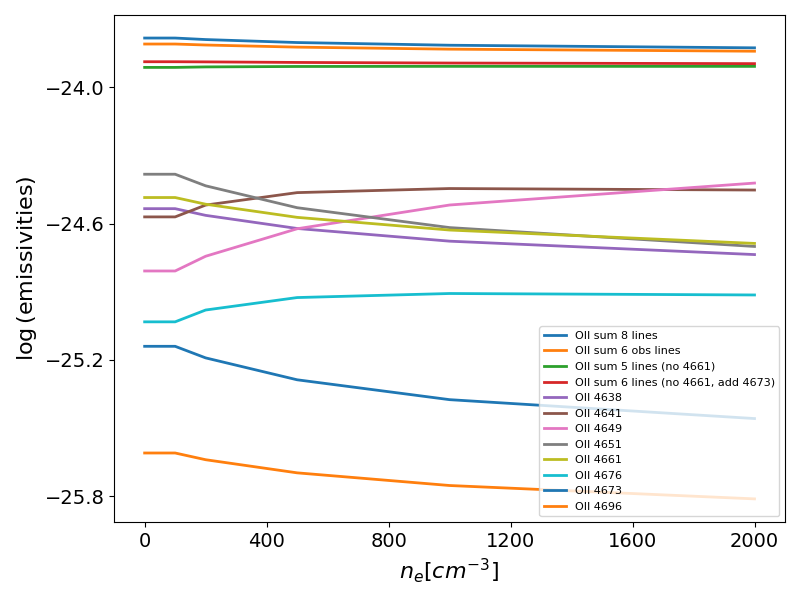

In [65]:
# let's see how the emissivities of each line and summ of all lines varies with density for a fixed te


# Define Te and ne grids
te_grid = np.linspace(5000, 15000, 10)
ne = [0, 50, 100, 200, 500, 1000, 2000] #0, 50, 100, 200, 500, 1000, 2000

te = 10000
#for j, ne in enumerate(ne_grid):

emis_OII_all = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl)
               for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23, 4673.73, 4696.35]) #4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23, 4673.73, 4696.35

emis_OII_obs = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl)
               for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23]) 

emis_OII_obs_wo_61 = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl)
               for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4676.23]) #4661.63, 

emis_OII_obs_wo_61_76 = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl)
               for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4673.73, 4676.23]) #4661.63, 4676.23

emis_4638 = O2r.getEmissivity(tem=te, den=ne, wave=4638.86)
emis_4641 = O2r.getEmissivity(tem=te, den=ne, wave=4641.81)
emis_4649 = O2r.getEmissivity(tem=te, den=ne, wave=4649.13)
emis_4651 = O2r.getEmissivity(tem=te, den=ne, wave=4650.84)
emis_4661 = O2r.getEmissivity(tem=te, den=ne, wave=4661.63)
emis_4676 = O2r.getEmissivity(tem=te, den=ne, wave=4676.23)
emis_4673 = O2r.getEmissivity(tem=te, den=ne, wave=4673.73)
emis_4696 = O2r.getEmissivity(tem=te, den=ne, wave=4696.35)

emis_5007 = O3.getEmissivity(tem=te, den=ne, wave=5006.84)


fig, (ax1) = plt.subplots(figsize=(8, 6)) #, sharex=True

# --- First plot ---
ax1.plot(ne, np.log10(emis_OII_all), linestyle='-', linewidth=2, label=f'OII sum 8 lines')
ax1.plot(ne, np.log10(emis_OII_obs), linestyle='-', linewidth=2, label=f'OII sum 6 obs lines')
ax1.plot(ne, np.log10(emis_OII_obs_wo_61), linestyle='-', linewidth=2, label=f'OII sum 5 lines (no 4661)')
ax1.plot(ne, np.log10(emis_OII_obs_wo_61_76), linestyle='-', linewidth=2, label=f'OII sum 6 lines (no 4661, add 4673)')

ax1.plot(ne, np.log10(emis_4638), linestyle='-', linewidth=2, label=f'OII 4638')
ax1.plot(ne, np.log10(emis_4641), linestyle='-', linewidth=2, label=f'OII 4641')
ax1.plot(ne, np.log10(emis_4649), linestyle='-', linewidth=2, label=f'OII 4649')
ax1.plot(ne, np.log10(emis_4651), linestyle='-', linewidth=2, label=f'OII 4651')
ax1.plot(ne, np.log10(emis_4661), linestyle='-', linewidth=2, label=f'OII 4661')
ax1.plot(ne, np.log10(emis_4676), linestyle='-', linewidth=2, label=f'OII 4676')
ax1.plot(ne, np.log10(emis_4673), linestyle='-', linewidth=2, label=f'OII 4673')
ax1.plot(ne, np.log10(emis_4696), linestyle='-', linewidth=2, label=f'OII 4696')


#ax1.plot(ne_grid, np.log10(emis_OII_all/emis_5007), linestyle='-', linewidth=2, label=f'OII all/[OIII]5007')
#ax1.plot(ne_grid, np.log10(emis_OII_obs/emis_5007), linestyle='-', linewidth=2, label=f'OII obs/[OIII]5007')

ax1.set_ylabel(r'$\log$(emissivities)', fontsize=16)
ax1.set_xlabel(r'$n_e[cm^{-3}]$', fontsize=16)
ax1.legend(loc='best', fontsize=8)
ax1.tick_params(axis='both', labelsize=14)

ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax1.yaxis.set_major_locator(MaxNLocator(nbins=4))

plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/pyneb_plots/oii_sums_lines_vs_ne.png')
plt.show()


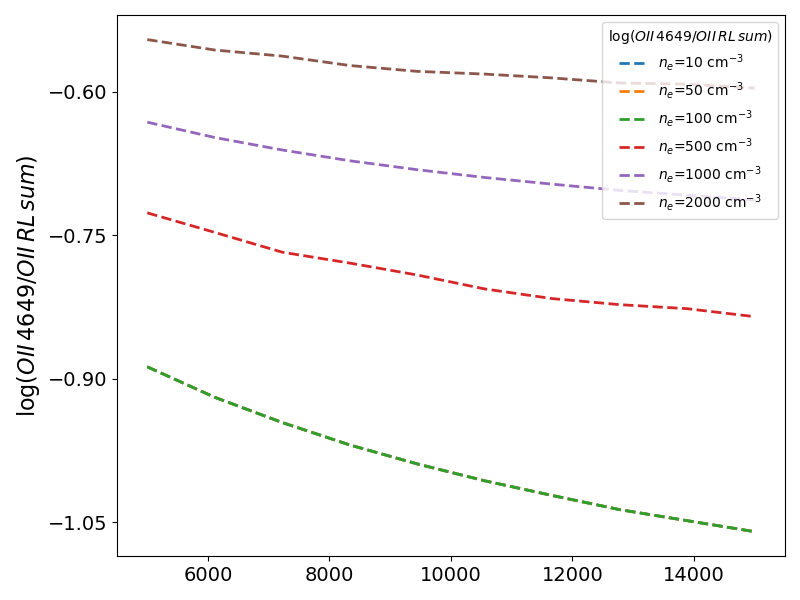

In [6]:
# testing fig 2 from ruiz 2003

# Define Te and ne grids
te_grid = np.linspace(5000, 15000, 10)
ne_grid = [10, 50, 100, 500, 1000, 2000]

# Compute theoretical OII/[OIII] ratio grid
ratio1_grid = np.zeros((len(te_grid), len(ne_grid)))
ratio2_grid = np.zeros((len(te_grid), len(ne_grid)))

for i, te in enumerate(te_grid):
    for j, ne in enumerate(ne_grid):

        emis_4649 = O2r.getEmissivity(tem=te, den=ne, wave=4649.13)

        emis_OII = sum(O2r.getEmissivity(tem=te, den=ne, wave=wl)
                       for wl in [4638.86, 4641.81, 4649.13, 4650.84, 4661.63, 4676.23]) #4638.86, , 4641.81, 4649.13, 4650.84, 4661.63, 4676.23, 4673.73, 4696.35
        emis_OIII = O3.getEmissivity(tem=te, den=ne, wave=5006.84)
        emis_hb = H1.getEmissivity(tem =te, den=ne, wave=4861)

        ratio1_grid[i, j] = emis_4649/emis_OII 


# Create shared x-axis subplots
#fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
        
fig, (ax1) = plt.subplots(figsize=(8, 6)) #, sharex=True

# --- First plot ---
for j, ne in enumerate(ne_grid):
    ax1.plot(te_grid, np.log10(ratio1_grid[:, j]), linestyle='--', linewidth=2, label=f'$n_e$={ne:.0f} cm$^{{-3}}$')
    
ax1.set_ylabel(r'$\log(OII\,4649/OII\, RL\,sum$)', fontsize=16)
ax1.set_ylim()
ax1.legend(loc='upper right', fontsize=10, title=r'$\log(OII\,4649/OII\, RL\,sum$)')
ax1.tick_params(axis='both', labelsize=14)
ax3.tick_params(axis='both', labelsize=14)


ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))

ax1.yaxis.set_major_locator(MaxNLocator(nbins=4))

plt.tight_layout()
plt.subplots_adjust(hspace=0)
#plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/pyneb_plots/pyneb_combined_oii_[OIII]4363_vs_5007_ratios_vs_Te.png')
plt.show()

        

In [16]:
# Peimbbert 67 annd Esteban 99

def compute_t0_t2_integral(Te, Ne, Ni):
    """
    Compute T0 and t^2 following Peimbert (1967), using volume-weighted integrals.

    Te : array-like
        Electron temperature at each position (K)
    Ne : array-like
        Electron density (nne[SII]) at each position (cm^-3)
    Ni : array-like
        Ion density ( O++ abundance) at each position
    """
    weight = Ne * Ni
    numerator_T0 = np.nansum(Te * weight)
    denominator_T0 = np.nansum(weight)

    T0 = numerator_T0 / denominator_T0

    numerator_t2 = np.nansum(((Te - T0)**2) * weight)
    denominator_t2 = T0**2 * denominator_T0

    t2 = numerator_t2 / denominator_t2

    return T0, t2

T0_spaxel, t2_spaxel = compute_t0_t2_integral(teo3cel, nes2, 10 **(12-diag["Opp_cel"]))

T0rl_spaxel, t2rl_spaxel = compute_t0_t2_integral(teo3rl, nes2, 10 **(12-diag["Opp_RL"]))
T0rl_bin, t2rl_bin = compute_t0_t2_integral(teo3rl_bin, nes2_bin, 10 **(12-diag_binned["Opp_RL"]))

print("Spaxel T0 and t^2:", T0_spaxel, t2_spaxel)


Spaxel T0 and t^2: 14525.776584403204 0.06042971014451474


In [8]:
def explore_adf(x, y, xerr, yerr, x_bin, y_bin, xerr_bin, yerr_bin, x_int, y_int, xerr_int, yerr_int, x_ell,
                y_ell, xerr_ell, yerr_ell, x_cen, y_cen, xerr_cen, yerr_cen, sel, sel_bin, sel_ell, colorcode, colorcode_bin, colorcode_ell,
                xmin, xmax, ymin, ymax, xlabel, ylabel, title, figname):

    # Valid mask to remove NaN or infinite values
    valid_mask = np.isfinite(x[sel]) & np.isfinite(y[sel])
    valid_mask_bin = np.isfinite(x_bin[sel_bin]) & np.isfinite(y_bin[sel_bin])
    valid_mask_ell = np.isfinite(x_ell[sel_ell]) & np.isfinite(y_ell[sel_ell])

    print(f"Resolved valid points: {np.sum(valid_mask)}")
    print(f"Binned valid points: {np.sum(valid_mask_bin)}")
    print(f"Elliptical valid points: {np.sum(valid_mask_ell)}")


     #=========================================================================================================#  

    #if np.sum(valid_mask) > 1:
    if (
    np.sum(valid_mask) > 1 and
    np.sum(valid_mask_bin) > 1 and
    np.sum(valid_mask_ell) > 1):

        
        # Compute Pearson correlation coefficient for resolved spaxels
        corr_coeff, p_value = pearsonr(y[sel][valid_mask], x[sel][valid_mask])
        print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")

        # Compute Pearson correlation coefficient  for binned measurements
        corr_coeff_bin, p_value_bin = pearsonr(y_bin[sel_bin][valid_mask_bin], x_bin[sel_bin][valid_mask_bin])
        print(f"Correlation coefficient: {corr_coeff_bin:.2f}, p-value: {p_value_bin:.3g}")

        # Compute Pearson correlation coefficient  for ELLIPTICAL binned measurements near Her 36
        corr_coeff_ell, p_value_ell = pearsonr(y_ell[sel_ell][valid_mask_ell], x_ell[sel_ell][valid_mask_ell])
        print(f"Correlation coefficient: {corr_coeff_ell:.2f}, p-value: {p_value_ell:.3g}")


        #=========================================================================================================#  


        # Define x and y
        x_axis = x[sel][valid_mask].reshape(-1, 1)
        y_axis = y[sel][valid_mask].reshape(-1, 1)

        x_axis_bin = x_bin[sel_bin][valid_mask_bin].reshape(-1, 1)
        y_axis_bin = y_bin[sel_bin][valid_mask_bin].reshape(-1, 1)

        x_axis_ell = x_ell[sel_ell][valid_mask_ell].reshape(-1, 1)
        y_axis_ell = y_ell[sel_ell][valid_mask_ell].reshape(-1, 1)

        #=========================================================================================================#  
        '''
        # Theil-Sen fit for resolved
        model = TheilSenRegressor().fit(x_axis, y_axis)
        slope = model.coef_[0]
        intercept = model.intercept_

        # Theil-Sen fit for binned
        model_bin = TheilSenRegressor().fit(x_axis_bin, y_axis_bin)
        slope_bin = model_bin.coef_[0]
        intercept_bin = model_bin.intercept_

        # Theil-Sen fit for NGC 6523
        model_ell = TheilSenRegressor().fit(x_axis_ell, y_axis_ell)
        slope_ell = model_ell.coef_[0]
        intercept_ell = model_ell.intercept_

        #=========================================================================================================#  

        # Compute line fit for resolved data
        x_fit = np.linspace(x_axis.min(), x_axis.max(), 500)
        y_fit = slope * x_fit + intercept

        x_fit_bin = np.linspace(x_axis_bin.min(), x_axis_bin.max(), 500)
        y_fit_bin = slope_bin * x_fit_bin + intercept_bin

        x_fit_ell = np.linspace(x_axis_ell.min(), x_axis_ell.max(), 500)
        y_fit_ell = slope_ell * x_fit_ell + intercept_ell
        '''
        #=========================================================================================================#  

        ############################################# plotting #####################################################
        fig, ax = plt.subplots(figsize=(10, 6))

        plt.rcParams.update({'axes.titlesize': '14',
                     'axes.labelsize':'22',
                     'axes.linewidth':     '2' ,
                     'ytick.labelsize': '22.0',
                     'xtick.labelsize': '22.0',
                     'font.size': '14.0',
                     'legend.fontsize':'14'})
    

        # Plot scatter with no color to scatters + robust fit
        plt.errorbar(x[sel], y[sel], yerr=yerr[sel], xerr=xerr[sel], fmt='None', ecolor='grey', alpha=0.2, zorder=0)

        plt.errorbar(x_bin[sel_bin], y_bin[sel_bin], yerr=yerr_bin[sel_bin], xerr=xerr_bin[sel_bin], 
             fmt='None', ecolor='k', alpha=1, zorder=0)
        
        plt.errorbar(x_ell[sel_ell], y_ell[sel_ell], yerr=yerr_ell[sel_ell], xerr=xerr_ell[sel_ell], fmt='None', 
                     ecolor='b', alpha=1, zorder=0)
        
        plt.errorbar(x_int, y_int, yerr = yerr_int, xerr = xerr_int, c='black', fmt='P',  ecolor='b', ms = 8, alpha = 0.9, label = 'M8 Integrated')
        
        plt.errorbar(x_ell[0], y_ell[0], yerr=yerr_ell[0], xerr=xerr_ell[0], c = 'magenta', fmt='D',  ecolor='magenta', ms = 8, alpha = 0.9, label = 'Her36 + HG region')
        #=========================================================================================================#  

        # color-code
        sc1 = ax.scatter(x[sel], y[sel], c=colorcode[sel], cmap='viridis', marker='.', 
                 s=40,  alpha=0.6, label=fr'Spaxels')    #$\rho$(): {corr_coeff:.2f}, p-value: {p_value:.3g}
        
        sc2 = ax.scatter(x_bin[sel_bin], y_bin[sel_bin], c=colorcode_bin[sel_bin], 
                 cmap='Reds', marker='*', alpha=1, edgecolors='k', linewidth =0.6, 
                 s=90, label=fr'Annular bins')     #)$\rho$ (): {corr_coeff_bin:.2f}, p-value: {p_value_bin:.3g}

        sc3 = ax.scatter(x_ell[sel_ell], y_ell[sel_ell], c=colorcode_ell[sel_ell], 
                 cmap='Greens', marker='D', alpha=0.8, edgecolors='k', linewidth =0.6, 
                 s=80, label=fr'NGC 6523 annular bins') #$\rho$ ()): {corr_coeff_ell:.2f}, p-value: {p_value_ell:.3g}
        
        #sc3 = ax.scatter(x_ell[0], y_ell[sel_ell], c=colorcode_ell[sel_ell], 
        #         cmap='Magenta', marker='D', alpha=0.8, edgecolors='k', linewidth =0.6, 
        #         s=80, label=fr'NGC 6523 annular bins') 

        # Highlight spaxels near the center with an extra edge
        #sc4=ax.scatter(x[highlight], y[highlight], facecolors='none', edgecolors='lime', s=50, linewidths=2.5, label='Hourglass + Her36')

        # best fit lines 
        #plt.plot(x_fit, y_fit, 'b', linestyle ='--', linewidth=1.5, label='Best fit (Resolved)')
        #plt.plot(x_fit_bin, y_fit_bin, c='r', linestyle ='--', linewidth=1.5, label='Best fit (Annular bins)')
        #plt.plot(x_fit_ell, y_fit_ell, c='g', linestyle ='--', linewidth=1.5, label='Best fit (NGC 6523)')

        #fig.colorbar(sc1, ax=ax, label='R (arcmin)')
        #fig.colorbar(sc2, ax=ax, label='Binned R (arcmin)')

        ############################################# equations #####################################################

        # Best fit equations
        #print(fr"Best-fit line equation: {ylabel} = {slope:.4f} * {xlabel} + {intercept:.4f}")
        #print(fr"Best-fit line equation: {ylabel} = {slope_bin:.4f} * {xlabel} + {intercept_bin:.4f}")
        #print(fr"Best-fit line equation: {ylabel} = {slope_ell:.4f} * {xlabel} + {intercept_ell:.4f}")


        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax)

        plt.ylabel(ylabel)
        plt.xlabel(xlabel) 

        plt.legend(loc='best', framealpha=0.1)
        #plt.title(title)

        # Append axes to the right of ax, with width equal to 5% of ax, and padding equal to 0.05 inch
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="1.5%", pad=1e-4)
        cbar = fig.colorbar(sc1, cax=cax, fraction=0.042, label=r'$R_{resolved}$ [arcmin]')

        cax1 = divider.append_axes("right", size="1.5%", pad=0.9)
        cbar1 = fig.colorbar(sc2, cax=cax1, fraction=0.6, label=r'$R_{Annuli}$ [arcmin]')

        cax2 = divider.append_axes("right", size="1.5%", pad=1.2)
        cbar2 = fig.colorbar(sc3, cax=cax2, fraction=0.8, label=r'$R_{NGC 6523}$ [arcmin]')


        plt.tight_layout()
        
        #plt.savefig(f'{base_dir}{figname}.png', dpi=300)

        plt.close()
    

In [49]:

sn = [3] # 3, 4, 8, 10 

cen_del_te = central_spaxel_del_te
cen_del_te_err = central_spaxel_del_te_err

print(ell_snr_orl_binned.shape, ell_del_te_bin.shape, ell_adf_bin.shape, ell_del_te_err_bin.shape, ell_adf_err_bin.shape)

for i in sn:

    sel_orl =  (snr_orl > i)  & (snr_cel> i)
    sel_orl_binned = (snr_orl_binned  > i) & (snr_cel_binned > i)
    snr_ell =  (ell_snr_orl_binned > i) & (ell_snr_cel_binned > i)
    
    xlabel = r'$\Delta T_e^{(CELs-RLs/CEL)} O^{2+}$[K]'

    ylabel='ADF [dex]'
    title= f'ADF vs $\Delta {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_delta_te_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin) #np.log10
    colorcode_ell = (ell_r_bin)

    explore_adf(del_te, res_adf, del_te_err, res_adf_err, del_te_bin, adf_bin, del_te_err_bin, adf_err_bin, del_te_int, adf_int, del_te_err_int, 
    adf_err_int, ell_del_te_bin, ell_adf_bin, ell_del_te_err_bin, ell_adf_err_bin, cen_del_te, central_spaxel_adf, cen_del_te_err, central_spaxel_adf_err, 
    sel_orl, sel_orl_binned, snr_ell,
    colorcode, colorcode_bin, colorcode_ell, 100, 3600, 0, 1.2, xlabel, ylabel, title, figname)


(5,) (5,) (5,) (5,) (5,)
Resolved valid points: 1834
Binned valid points: 18
Elliptical valid points: 5
Correlation coefficient: 0.93, p-value: 0
Correlation coefficient: 0.80, p-value: 7.42e-05
Correlation coefficient: 0.99, p-value: 0.00136


In [19]:
sn = [3] # , 10

for i in sn:

    sel_orl =  (snr_orl > i)  & (snr_cel> i)
    sel_orl_binned = (snr_orl_binned  > i) & (snr_cel_binned > i)
    snr_ell =  (ell_snr_orl_binned > i) & (ell_snr_cel_binned > i)
    
    xlabel = r'$T_e^{CEL}O^{2+} $[K]'

    ylabel='ADF [dex]'
    title= fr'ADF vs {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_teocel_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin)  #_log_r
    colorcode_bin = (distance_bin)
    colorcode_ell = (ell_r_bin)

    explore_adf(teo3cel, res_adf, teo3celerr, res_adf_err, 
                teo3cel_bin, adf_bin, teo3celerr_bin, adf_err_bin, 
                teo3cel_int, adf_int, teo3celerr_int, adf_err_int, 
                ell_teo3cel_bin, ell_adf_bin, ell_teo3celerr_bin, ell_adf_err_bin,
                
                sel_orl, sel_orl_binned, snr_ell, 
                
                colorcode, colorcode_bin, colorcode_ell, 
                
                6000, 10000, 0, 1.2, xlabel, ylabel, title, figname)


Resolved valid points: 1834
Binned valid points: 19
Elliptical valid points: 5
Correlation coefficient: 0.73, p-value: 4.28e-300
Correlation coefficient: 0.91, p-value: 4.23e-08
Correlation coefficient: 0.65, p-value: 0.231


In [20]:
sn = [0, 3] # , 10

for i in sn:

    sel_orl =  (snr_orl > i)  & (snr_cel> i)
    sel_orl_binned = (snr_orl_binned  > i) & (snr_cel_binned > i)
    snr_ell =  (ell_snr_orl_binned > i) & (ell_snr_cel_binned > i)
    
    xlabel = r'$T_e^{RL}O^{2+} $[K]'

    ylabel='ADF [dex]'
    title= fr'ADF vs {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_teorl_errorbar_resolved_int_binned_snr_{i}'

    colorcode = (angular_distances_arcmin)
    colorcode_bin = (distance_bin)
    colorcode_ell = (ell_r_bin)

    explore_adf(teo3rl, adf, teo3rlerr, adf_err, 
                teo3rl_bin, adf_bin, teo3rlerr_bin, adf_err_bin, 
                teo3rl_int, adf_int, teo3rlerr_int, adf_err_int, 
                ell_teo3rl_bin, ell_adf_bin, ell_teo3rlerr_bin, ell_adf_err_bin,
                sel_orl, sel_orl_binned, snr_ell, 
                colorcode, colorcode_bin, colorcode_ell,
    3000, 7500, 0, 1.2, xlabel, ylabel, title, figname)


Resolved valid points: 12800
Binned valid points: 35
Elliptical valid points: 5
Correlation coefficient: -0.75, p-value: 0
Correlation coefficient: -0.93, p-value: 3.51e-16
Correlation coefficient: -0.75, p-value: 0.141
Resolved valid points: 1834
Binned valid points: 19
Elliptical valid points: 5
Correlation coefficient: -0.79, p-value: 0
Correlation coefficient: -0.96, p-value: 5.23e-11
Correlation coefficient: -0.75, p-value: 0.141


In [22]:
sn = [3] # , 8, 10

for i in sn:
    print(i)
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    snr_ell =  ell_snr_orl_binned > i
    
    xlabel = r'12+log$(O^{2+}/H^{+})_{CEL}$'

    ylabel='ADF [dex]'
    title= fr'ADF vs {xlabel} ([OIII] 4363, S/N > {i})'
    figname= f'robust_fit_ADF_vs_Oppcel_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin)
    colorcode_ell = (ell_r_bin)

    explore_adf(diag['Opp_cel'], adf, diag['Opp_cel_err'], adf_err, 
                diag_binned['Opp_cel'], adf_bin, diag_binned['Opp_cel_err'], adf_err_bin, 
                diag_int['Opp_cel'], adf_int, diag_int['Opp_cel_err'], adf_err_int, 
                ell_diag_binned['Opp_cel'], ell_adf_bin, ell_diag_binned['Opp_cel_err'], ell_adf_err_bin,
                sel_orl, sel_orl_binned, snr_ell,
                colorcode, colorcode_bin, colorcode_ell, 
    7.0, 8.5, 0, 1.2, xlabel, ylabel, title, figname)


3
Resolved valid points: 2096
Binned valid points: 21
Elliptical valid points: 5
Correlation coefficient: -0.85, p-value: 0
Correlation coefficient: -0.97, p-value: 1.23e-13
Correlation coefficient: -0.57, p-value: 0.314


In [23]:
sn = [3] # , 5, 8, 10

for i in sn:
    print(i)
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    snr_ell =  ell_snr_orl_binned > i
    
    xlabel = r'12+log$(O^{2+}/H^{+})_{RL}$'

    ylabel='ADF [dex]'
    title= fr'ADF vs {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_Opprl_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin)
    colorcode_ell = (ell_r_bin)

    explore_adf(diag['Opp_RL'], adf, diag['Opp_RL_err'], adf_err, 
                diag_binned['Opp_RL'], adf_bin, diag_binned['Opp_RL_err'], adf_err_bin, 
                diag_int['Opp_RL'], adf_int, diag_int['Opp_RL_err'], adf_err_int, 
                ell_diag_binned['Opp_RL'], ell_adf_bin, ell_diag_binned['Opp_RL_err'], ell_adf_err_bin,
                sel_orl, sel_orl_binned, snr_ell,
                colorcode, colorcode_bin, colorcode_ell,
    8.3, 9.2, 0, 1.2, xlabel, ylabel, title, figname)


3
Resolved valid points: 2096
Binned valid points: 21
Elliptical valid points: 5
Correlation coefficient: 0.78, p-value: 0
Correlation coefficient: 0.85, p-value: 1.18e-06
Correlation coefficient: 0.31, p-value: 0.61


Resolved valid points: 1834
Binned valid points: 18
Elliptical valid points: 5

--- Resolved Spaxels ---
Pearson r = 0.114, p = 9.28e-07
Spearman ρ = 0.164, p = 1.66e-12
Kendall τ = 0.114, p = 3e-13

--- Annular Bins ---
Pearson r = 0.681, p = 0.00187
Spearman ρ = 0.624, p = 0.00561
Kendall τ = 0.503, p = 0.00299

--- NGC 6523 Annuli ---
Pearson r = 0.822, p = 0.088
Spearman ρ = 1.000, p = 1.4e-24
Kendall τ = 1.000, p = 0.0167


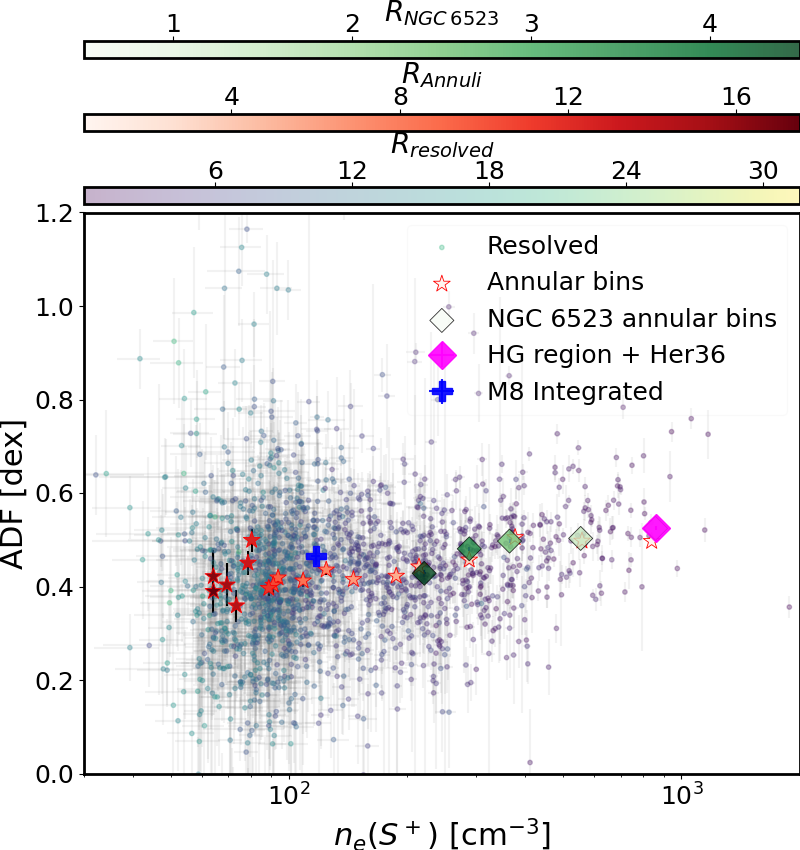

In [38]:
def explore_adf(x, y, xerr, yerr, x_bin, y_bin, xerr_bin, yerr_bin, x_int, y_int, xerr_int, yerr_int, x_ell,
                y_ell, xerr_ell, yerr_ell, x_cen, y_cen, xerr_cen, yerr_cen, sel, sel_bin, sel_ell, colorcode, colorcode_bin, colorcode_ell,
                xmin, xmax, ymin, ymax, xlabel, ylabel, title, figname):

    # Valid mask to remove NaN or infinite values
    valid_mask = np.isfinite(x[sel]) & np.isfinite(y[sel])
    valid_mask_bin = np.isfinite(x_bin[sel_bin]) & np.isfinite(y_bin[sel_bin])
    valid_mask_ell = np.isfinite(x_ell[sel_ell]) & np.isfinite(y_ell[sel_ell])

    print(f"Resolved valid points: {np.sum(valid_mask)}")
    print(f"Binned valid points: {np.sum(valid_mask_bin)}")
    print(f"Elliptical valid points: {np.sum(valid_mask_ell)}")


     #=========================================================================================================#  

    #if np.sum(valid_mask) > 1:
    if (
    np.sum(valid_mask) > 1 and
    np.sum(valid_mask_bin) > 1 and
    np.sum(valid_mask_ell) > 1):

        
        # Compute Pearson correlation coefficient for resolved spaxels
        corr_coeff, p_value = pearsonr(y[sel][valid_mask], x[sel][valid_mask])

        # Compute Pearson correlation coefficient  for binned measurements
        corr_coeff_bin, p_value_bin = pearsonr(y_bin[sel_bin][valid_mask_bin], x_bin[sel_bin][valid_mask_bin])

        # Compute Pearson correlation coefficient  for ELLIPTICAL binned measurements near Her 36
        corr_coeff_ell, p_value_ell = pearsonr(y_ell[sel_ell][valid_mask_ell], x_ell[sel_ell][valid_mask_ell])


        #=========================================================================================================#

        # ================= RESOLVED =================
        x_res = x[sel][valid_mask]
        y_res = y[sel][valid_mask]
        
        pear_res, p_pear_res = pearsonr(x_res, y_res)
        spear_res, p_spear_res = spearmanr(x_res, y_res)
        kend_res, p_kend_res = kendalltau(x_res, y_res)
        
        print("\n--- Resolved Spaxels ---")
        print(f"Pearson r = {pear_res:.3f}, p = {p_pear_res:.3g}")
        print(f"Spearman ρ = {spear_res:.3f}, p = {p_spear_res:.3g}")
        print(f"Kendall τ = {kend_res:.3f}, p = {p_kend_res:.3g}")
        
        
        # ================= ANNULAR BINS =================
        x_b = x_bin[sel_bin][valid_mask_bin]
        y_b = y_bin[sel_bin][valid_mask_bin]
        
        pear_bin, p_pear_bin = pearsonr(x_b, y_b)
        spear_bin, p_spear_bin = spearmanr(x_b, y_b)
        kend_bin, p_kend_bin = kendalltau(x_b, y_b)
        
        print("\n--- Annular Bins ---")
        print(f"Pearson r = {pear_bin:.3f}, p = {p_pear_bin:.3g}")
        print(f"Spearman ρ = {spear_bin:.3f}, p = {p_spear_bin:.3g}")
        print(f"Kendall τ = {kend_bin:.3f}, p = {p_kend_bin:.3g}")
        
        
        # ================= NGC 6523 (ELLIPTICAL) =================
        x_e = x_ell[sel_ell][valid_mask_ell]
        y_e = y_ell[sel_ell][valid_mask_ell]
        
        pear_ell, p_pear_ell = pearsonr(x_e, y_e)
        spear_ell, p_spear_ell = spearmanr(x_e, y_e)
        kend_ell, p_kend_ell = kendalltau(x_e, y_e)
        
        print("\n--- NGC 6523 Annuli ---")
        print(f"Pearson r = {pear_ell:.3f}, p = {p_pear_ell:.3g}")
        print(f"Spearman ρ = {spear_ell:.3f}, p = {p_spear_ell:.3g}")
        print(f"Kendall τ = {kend_ell:.3f}, p = {p_kend_ell:.3g}")


        #=========================================================================================================#  


        # Define x and y
        x_axis = x[sel][valid_mask].reshape(-1, 1)
        y_axis = y[sel][valid_mask].reshape(-1, 1)

        x_axis_bin = x_bin[sel_bin][valid_mask_bin].reshape(-1, 1)
        y_axis_bin = y_bin[sel_bin][valid_mask_bin].reshape(-1, 1)

        x_axis_ell = x_ell[sel_ell][valid_mask_ell].reshape(-1, 1)
        y_axis_ell = y_ell[sel_ell][valid_mask_ell].reshape(-1, 1)

        #=========================================================================================================#  
        '''
        # Theil-Sen fit for resolved
        model = TheilSenRegressor().fit(x_axis, y_axis)
        slope = model.coef_[0]
        intercept = model.intercept_

        # Theil-Sen fit for binned
        model_bin = TheilSenRegressor().fit(x_axis_bin, y_axis_bin)
        slope_bin = model_bin.coef_[0]
        intercept_bin = model_bin.intercept_

        # Theil-Sen fit for NGC 6523
        model_ell = TheilSenRegressor().fit(x_axis_ell, y_axis_ell)
        slope_ell = model_ell.coef_[0]
        intercept_ell = model_ell.intercept_

        #=========================================================================================================#  

        # Compute line fit for resolved data
        x_fit = np.linspace(x_axis.min(), x_axis.max(), 500)
        y_fit = slope * x_fit + intercept

        x_fit_bin = np.linspace(x_axis_bin.min(), x_axis_bin.max(), 500)
        y_fit_bin = slope_bin * x_fit_bin + intercept_bin

        x_fit_ell = np.linspace(x_axis_ell.min(), x_axis_ell.max(), 500)
        y_fit_ell = slope_ell * x_fit_ell + intercept_ell
        '''
        #=========================================================================================================#  

        ############################################# plotting #####################################################
        fig, ax = plt.subplots(figsize=(8, 8.5))

        plt.rcParams.update({'axes.titlesize': '14',
                     'axes.labelsize':'22',
                     'axes.linewidth':     '2' ,
                     'ytick.labelsize': '18.0',
                     'xtick.labelsize': '18.0',
                     'font.size': '20.0',
                     'legend.fontsize':'18'})
    

        # Plot scatter with no color to scatters + robust fit
        plt.errorbar(x[sel], y[sel], yerr=yerr[sel], xerr=xerr[sel], fmt='None', ecolor='grey', alpha=0.1, zorder=0)

        plt.errorbar(x_bin[sel_bin], y_bin[sel_bin], yerr=yerr_bin[sel_bin], xerr=xerr_bin[sel_bin], 
             fmt='None', ecolor='k', alpha=1, zorder=0)
        
        plt.errorbar(x_ell[sel_ell], y_ell[sel_ell], yerr=yerr_ell[sel_ell], xerr=xerr_ell[sel_ell], fmt='None', 
                     ecolor='b', alpha=1, zorder=0)
        
        plt.errorbar(x_ell[0], y_ell[0], yerr=yerr_ell[0], xerr=xerr_ell[0], c = 'magenta', fmt='D',  ecolor='magenta', ms = 14, alpha = 0.9, label = 'HG region + Her36')
        
        plt.errorbar(x_int, y_int, yerr = yerr_int, xerr = xerr_int, c='b', fmt='P',  ecolor='b', ms = 14, alpha = 0.9, label = 'M8 Integrated')
        #plt.errorbar(x_cen, y_cen, yerr=yerr_cen, xerr=xerr_cen, c = 'magenta', fmt='*',  ecolor='magenta', ms = 9, alpha = 0.9, label = 'HG + Her36')
        

        #=========================================================================================================#  
        # color-code
        sc1 = ax.scatter(x[sel], y[sel], c=colorcode[sel], cmap='viridis', marker='.', 
                 s=40,  alpha=0.3, label=fr'Resolved')    #$\rho$(): {corr_coeff:.2f}, p-value: {p_value:.3g}
        
        sc2 = ax.scatter(x_bin[sel_bin], y_bin[sel_bin], c=colorcode_bin[sel_bin], 
                 cmap='Reds', marker='*', alpha=1, edgecolors='r', linewidth =0.6, 
                 s=160, label=fr'Annular bins')     #)$\rho$ (): {corr_coeff_bin:.2f}, p-value: {p_value_bin:.3g}

        sc3 = ax.scatter(x_ell[sel_ell], y_ell[sel_ell], c=colorcode_ell[sel_ell], 
                 cmap='Greens', marker='D', alpha=0.8, edgecolors='k', linewidth =0.6, 
                 s=150, label=fr'NGC 6523 annular bins') #$\rho$ ()): {corr_coeff_ell:.2f}, p-value: {p_value_ell:.3g}

        # Highlight spaxels near the center with an extra edge
        #sc4=ax.scatter(x[highlight], y[highlight], facecolors='none', edgecolors='lime', s=50, linewidths=2.5, label='Hourglass + Her36')

        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax)

        plt.xscale('log')

        plt.ylabel(ylabel)
        plt.xlabel(xlabel) 

        plt.legend(loc='best', framealpha=0.1)
        #plt.title(title)

        #=========================== colorbars on y axis ==============================#
        # Append axes to the right of ax, with width equal to 5% of ax, and padding equal to 0.05 inch
        
        #divider = make_axes_locatable(ax)
        #cax = divider.append_axes("right", size="1.5%", pad=1e-4)
        #cbar = fig.colorbar(sc1, cax=cax, fraction=0.042, label=r'$R_{resolved}$ [arcmin]')

        #cax1 = divider.append_axes("right", size="1.5%", pad=0.9)
        #cbar1 = fig.colorbar(sc2, cax=cax1, fraction=0.6, label=r'$R_{Annuli}$ [arcmin]')

        #cax2 = divider.append_axes("right", size="1.5%", pad=1.2)
        #cbar2 = fig.colorbar(sc3, cax=cax2, fraction=0.8, label=r'$R_{NGC 6523}$ [arcmin]')

        #cbar2 = fig.colorbar(sc3, cax=cax2, fraction=0.8, label=r'$R_{NGC 6523}$ [arcmin]')

        #========================== colorars at x-axis ====================================#

        gap_from_plot = 0.01      # space between main plot and first colorbar
        gap_between_cb = 0.066     # space between colorbars
        cb_height = 0.02         # height of each colorbar

        # Leave enough room at the top (increase if needed)
        #plt.subplots_adjust(top=0.74, bottom=0.10)
        plt.subplots_adjust(left=0.105, right=0.9995, top=0.75, bottom=0.09)  # left=0.04 for oppccel

        box = ax.get_position()

        # --- First colorbar ---
        y1 = box.y1 + gap_from_plot
        cax1 = fig.add_axes([box.x0, y1, box.width, cb_height])
        cbar1 = fig.colorbar(sc1, cax=cax1, orientation='horizontal')
        cbar1.set_label(r'$R_{resolved}$', labelpad=4.5, fontsize = 20)
        cbar1.ax.xaxis.set_ticks_position('top')
        cbar1.ax.xaxis.set_label_position('top')

        # --- Second colorbar ---
        y2 = y1 + cb_height + gap_between_cb
        cax2 = fig.add_axes([box.x0, y2, box.width, cb_height])
        cbar2 = fig.colorbar(sc2, cax=cax2, orientation='horizontal')
        cbar2.set_label(r'$R_{Annuli}$', labelpad=2, fontsize = 20)
        cbar2.ax.xaxis.set_ticks_position('top')
        cbar2.ax.xaxis.set_label_position('top')

        # --- Third colorbar ---
        y3 = y2 + cb_height + gap_between_cb
        cax3 = fig.add_axes([box.x0, y3, box.width, cb_height])
        cbar3 = fig.colorbar(sc3, cax=cax3, orientation='horizontal')
        cbar3.set_label(r'$R_{NGC\,6523}$', labelpad=-6, fontsize = 20)  # units removed [arcmin]; labelpad=-1---15, to mange the position of color bar label position
        cbar3.ax.xaxis.set_ticks_position('top')
        cbar3.ax.xaxis.set_label_position('top')

        cbar1.ax.tick_params(labelsize=18, pad=-1)   # reduce number size, pad to move the color bar ticks in the gap
        cbar2.ax.tick_params(labelsize=18, pad=-1)
        cbar3.ax.tick_params(labelsize=18, pad=-1)

        cbar1.ax.xaxis.set_major_locator(MaxNLocator(6))
        cbar2.ax.xaxis.set_major_locator(MaxNLocator(5))
        cbar3.ax.xaxis.set_major_locator(MaxNLocator(4))


        #============================ Constrain layout and save the figure =========================#

        #plt.tight_layout()        
        plt.savefig(f'{base_dir}{figname}.pdf', dpi=500)
        

        plt.show()
    

sn = [3] # , 10
cen_nes2, cen_nes2_err = central_spaxel_diag['neS2'], central_spaxel_diag['neS2err']

for i in sn:

    sel_orl =  (snr_orl > i)  & (snr_cel> i)
    sel_orl_binned = (snr_orl_binned  > i) & (snr_cel_binned > i)
    snr_ell =  (ell_snr_orl_binned > i) & (ell_snr_cel_binned > i)
    
    xlabel = r'$n_e (S^+)$ [cm$^{-3}]$'
    ylabel='ADF [dex]'
    title= fr'ADF vs $n_e([SII])$ (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_nes2_errorbar_resolved_int_binned_snr_{i}'

    colorcode = (angular_distances_arcmin)
    colorcode_bin = (distance_bin)
    colorcode_ell = (ell_r_bin)


    explore_adf(nes2, res_adf, nes2err, res_adf_err, 
                nes2_bin, adf_bin, nes2err_bin, adf_err_bin, 
                nes2_int, adf_int, nes2err_int, adf_err_int, 
                ell_nes2_bin, ell_adf_bin, ell_nes2err_bin, ell_adf_err_bin, 
                cen_nes2, central_spaxel_adf, cen_nes2_err, central_spaxel_adf_err,
                sel_orl, sel_orl_binned, snr_ell,
                colorcode, colorcode_bin, colorcode_ell,
                30, 2000, 0, 1.2, xlabel, ylabel, title, figname)



In [47]:
if:

SyntaxError: invalid syntax (879943805.py, line 1)

In [8]:
def explore_adf(x, y, xerr, yerr, x_bin, y_bin, xerr_bin, yerr_bin, x_int, y_int, xerr_int, yerr_int, x_ell,
                y_ell, xerr_ell, yerr_ell, sel, sel_bin, sel_ell, colorcode, colorcode_bin, colorcode_ell,
                xmin, xmax, ymin, ymax, xlabel, ylabel, title, figname):

    # Valid mask to remove NaN or infinite values
    valid_mask = np.isfinite(x[sel]) & np.isfinite(y[sel])
    valid_mask_bin = np.isfinite(x_bin[sel_bin]) & np.isfinite(y_bin[sel_bin])
    valid_mask_ell = np.isfinite(x_ell[sel_ell]) & np.isfinite(y_ell[sel_ell])

    print(f"Resolved valid points: {np.sum(valid_mask)}")
    print(f"Binned valid points: {np.sum(valid_mask_bin)}")
    print(f"Elliptical valid points: {np.sum(valid_mask_ell)}")


     #=========================================================================================================#  

    #if np.sum(valid_mask) > 1:
    if (
    np.sum(valid_mask) > 1 and
    np.sum(valid_mask_bin) > 1 and
    np.sum(valid_mask_ell) > 1):

        
        # Compute Pearson correlation coefficient for resolved spaxels
        corr_coeff, p_value = pearsonr(y[sel][valid_mask], x[sel][valid_mask])
        print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")

        # Compute Pearson correlation coefficient  for binned measurements
        corr_coeff_bin, p_value_bin = pearsonr(y_bin[sel_bin][valid_mask_bin], x_bin[sel_bin][valid_mask_bin])
        print(f"Correlation coefficient: {corr_coeff_bin:.2f}, p-value: {p_value_bin:.3g}")

        # Compute Pearson correlation coefficient  for ELLIPTICAL binned measurements near Her 36
        corr_coeff_ell, p_value_ell = pearsonr(y_ell[sel_ell][valid_mask_ell], x_ell[sel_ell][valid_mask_ell])
        print(f"Correlation coefficient: {corr_coeff_ell:.2f}, p-value: {p_value_ell:.3g}")


        #=========================================================================================================#  


        # Define x and y
        x_axis = x[sel][valid_mask].reshape(-1, 1)
        y_axis = y[sel][valid_mask].reshape(-1, 1)

        x_axis_bin = x_bin[sel_bin][valid_mask_bin].reshape(-1, 1)
        y_axis_bin = y_bin[sel_bin][valid_mask_bin].reshape(-1, 1)

        x_axis_ell = x_ell[sel_ell][valid_mask_ell].reshape(-1, 1)
        y_axis_ell = y_ell[sel_ell][valid_mask_ell].reshape(-1, 1)

        #=========================================================================================================#  
        # Theil-Sen fit for resolved
        model = TheilSenRegressor().fit(x_axis, y_axis)
        slope = model.coef_[0]
        intercept = model.intercept_

        # Theil-Sen fit for binned
        model_bin = TheilSenRegressor().fit(x_axis_bin, y_axis_bin)
        slope_bin = model_bin.coef_[0]
        intercept_bin = model_bin.intercept_

        # Theil-Sen fit for NGC 6523
        model_ell = TheilSenRegressor().fit(x_axis_ell, y_axis_ell)
        slope_ell = model_ell.coef_[0]
        intercept_ell = model_ell.intercept_

        #=========================================================================================================#  

        # Compute line fit for resolved data
        x_fit = np.linspace(x_axis.min(), x_axis.max(), 500)
        y_fit = slope * x_fit + intercept

        x_fit_bin = np.linspace(x_axis_bin.min(), x_axis_bin.max(), 500)
        y_fit_bin = slope_bin * x_fit_bin + intercept_bin

        x_fit_ell = np.linspace(x_axis_ell.min(), x_axis_ell.max(), 500)
        y_fit_ell = slope_ell * x_fit_ell + intercept_ell

        #=========================================================================================================#  

        ############################################# plotting #####################################################
        fig, ax = plt.subplots(figsize=(12, 7))

        plt.rcParams.update({'axes.titlesize': '14',
                     'axes.labelsize':'18',
                     'axes.linewidth':     '1.8' ,
                     'ytick.labelsize': '18.0',
                     'xtick.labelsize': '18.0',
                     'font.size': '14.0',
                     'legend.fontsize':'13'})
    

        # Plot scatter with no color to scatters + robust fit
        plt.errorbar(x[sel], y[sel], yerr=yerr[sel], xerr=xerr[sel], fmt='None', ecolor='grey', alpha=0.2, zorder=0)

        plt.errorbar(x_bin[sel_bin], y_bin[sel_bin], yerr=yerr_bin[sel_bin], xerr=xerr_bin[sel_bin], 
             fmt='None', ecolor='k', alpha=1, zorder=0)
        
        plt.errorbar(x_ell[sel_ell], y_ell[sel_ell], yerr=yerr_ell[sel_ell], xerr=xerr_ell[sel_ell], fmt='None', 
                     ecolor='b', alpha=1, zorder=0)
        
        plt.errorbar(x_int, y_int, yerr = yerr_int, xerr = xerr_int, c='hotpink', fmt='P',  ecolor='b', ms = 8, alpha = 0.9, label = 'Integrated measurement')

        #=========================================================================================================#  

        # color-code
        sc1 = ax.scatter(x[sel], y[sel], c=colorcode[sel], cmap='viridis', marker='.', 
                 s=40,  alpha=1, edgecolors='k', linewidth =0.6, label=fr'$\rho$(Resolved): {corr_coeff:.2f}, p-value: {p_value:.3g}')
        
        sc2 = ax.scatter(x_bin[sel_bin], y_bin[sel_bin], c=colorcode_bin[sel_bin], 
                 cmap='Reds', marker='*', alpha=1, edgecolors='k', linewidth =0.6, 
                 s=90, label=fr'$\rho$ (Radial bins): {corr_coeff_bin:.2f}, p-value: {p_value_bin:.3g}')

        sc3 = ax.scatter(x_ell[sel_ell], y_ell[sel_ell], c=colorcode_ell[sel_ell], 
                 cmap='Greens', marker='D', alpha=0.8, edgecolors='k', linewidth =0.6, 
                 s=80, label=fr'$\rho$ (NGC 6523): {corr_coeff_ell:.2f}, p-value: {p_value_ell:.3g}')

        # Highlight spaxels near the center with an extra edge
        sc4=ax.scatter(x[highlight], y[highlight], facecolors='none', edgecolors='lime', s=50, linewidths=2.5, label='Hourglass + Her36')

        # best fit lines 
        plt.plot(x_fit, y_fit, 'b', linestyle ='--', linewidth=1.5, label='Best fit (Resolved)')
        plt.plot(x_fit_bin, y_fit_bin, c='r', linestyle ='--', linewidth=1.5, label='Best fit (Annular bins)')
        plt.plot(x_fit_ell, y_fit_ell, c='g', linestyle ='--', linewidth=1.5, label='Best fit (NGC 6523)')


        ############################################# equations #####################################################

        # Best fit equations
        print(fr"Best-fit line equation: {ylabel} = {slope:.4f} * {xlabel} + {intercept:.4f}")
        print(fr"Best-fit line equation: {ylabel} = {slope_bin:.4f} * {xlabel} + {intercept_bin:.4f}")
        print(fr"Best-fit line equation: {ylabel} = {slope_ell:.4f} * {xlabel} + {intercept_ell:.4f}")

        #theoretical relation between adf and delta te
        def adf_from_delta_te(delta_te, t0):
            #ADF (dex) as a function of del_Te and T0 using your formula
            F = (62140/t0) + 0.415 - (0.415 / ((29160/t0) + 0.415))
            return (6.86 * delta_te) / (t0 * F)     

        t0 = 8300
        # Delta Te
        delta_te = np.linspace(0, 10000, 10)
        
        adf = adf_from_delta_te(delta_te, t0)

        plt.plot(delta_te.flatten(), adf.flatten(), label=f"Theoretical relation")

        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax)

        plt.ylabel(ylabel)
        plt.xlabel(xlabel) 

        plt.legend(loc='best', framealpha=0.1)
        #plt.title(title)

        # Append axes to the right of ax, with width equal to 5% of ax, and padding equal to 0.05 inch
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="1.5%", pad=1e-4)
        cbar = fig.colorbar(sc1, cax=cax, fraction=0.042, label=r'$R_{resolved}$ [arcmin]')

        cax1 = divider.append_axes("right", size="1.5%", pad=0.9)
        cbar1 = fig.colorbar(sc2, cax=cax1, fraction=0.6, label=r'$R_{Annuli}$ [arcmin]')

        cax2 = divider.append_axes("right", size="1.5%", pad=0.9)
        cbar2 = fig.colorbar(sc3, cax=cax2, fraction=0.6, label=r'$R_{NGC 6523}$ [arcmin]')

        plt.tight_layout()
        
        dir = '/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/july2_25/'
        plt.savefig(f'{dir}{figname}_jul26.png', dpi=300)

        plt.show()
    

Resolved valid points: 1613
Binned valid points: 33
Elliptical valid points: 5
Correlation coefficient: 0.91, p-value: 0
Correlation coefficient: 0.99, p-value: 7.51e-27
Correlation coefficient: 0.99, p-value: 0.000917


/Users/amritasingh/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/amritasingh/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/amritasingh/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best-fit line equation: ADF [dex] = 0.0003 * $\Delta T_e^{(CEL-RL)} O^{2+}$ [K] + 0.0342
Best-fit line equation: ADF [dex] = 0.0003 * $\Delta T_e^{(CEL-RL)} O^{2+}$ [K] + 0.0487
Best-fit line equation: ADF [dex] = 0.0002 * $\Delta T_e^{(CEL-RL)} O^{2+}$ [K] + 0.0904


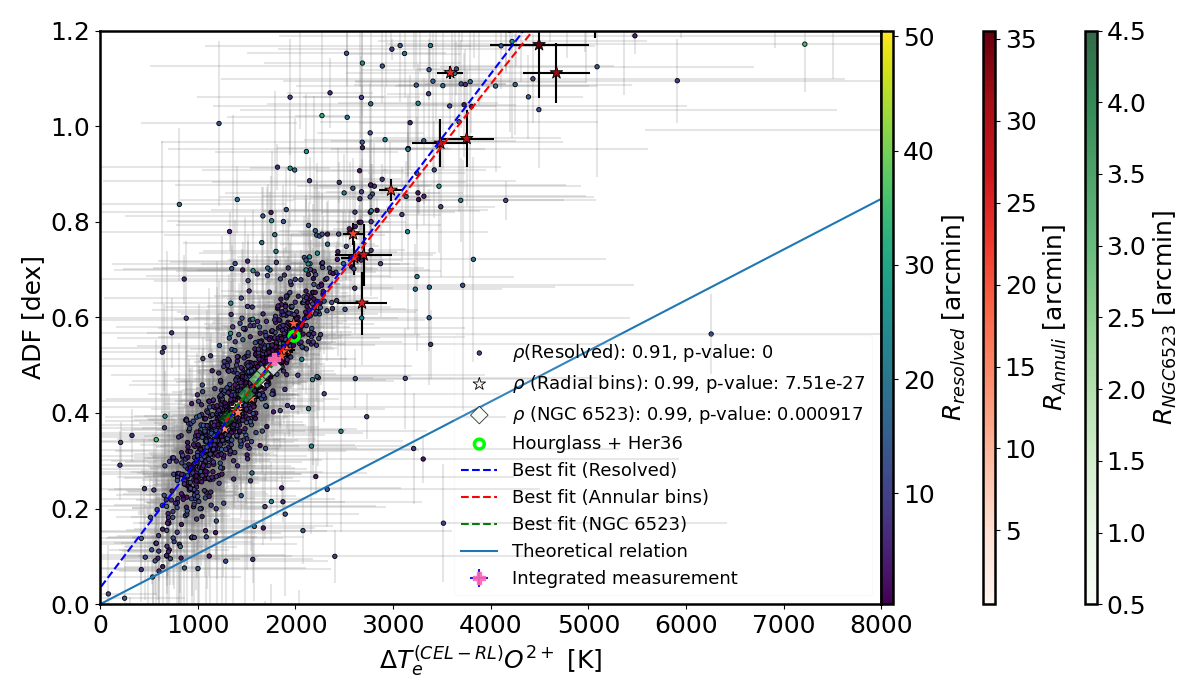

In [ ]:

sn = [3]

for i in sn:

    sel_orl = snr_orl > i
    sel_orl_binned = snr_orl_binned > i
    snr_ell = ell_snr_orl_binned > i

    xlabel = r'$\Delta T_e^{(CEL-RL)} O^{2+}$ [K]'
    ylabel = 'ADF [dex]'
    title = f'ADF vs {xlabel} (OII 4649+51, S/N > {i})'
    figname = f'robust_fit_ADF_vs_delta_te_errorbar_resolved_int_binned_snr_{i}_overplot_theo_relation_jul26'

    colorcode = angular_distances_arcmin
    colorcode_bin = distance_bin
    colorcode_ell = ell_r_bin

    # plotting function
    explore_adf(
        del_te, adf, del_te_err, adf_err,
        del_te_bin, adf_bin, del_te_err_bin, adf_err_bin,
        del_te_int, adf_int, del_te_err_int, adf_err_int,
        ell_del_te_bin, ell_adf_bin, ell_del_te_err_bin, ell_adf_err_bin,
        sel_orl, sel_orl_binned, snr_ell,
        colorcode, colorcode_bin, colorcode_ell,
        0, 8000, 0, 1.2,
        xlabel, ylabel, title, figname
    )



In [ ]:

ocel, ocelerr, ocelbin, ocelbinerr, ocelint, ocelinterr = elemental_abund_O(diag['Opp_cel'], diag['Opp_cel_err'], diag_binned['Opp_cel'], diag_binned['Opp_cel_err'], 
                  diag['Op_cel'], diag['Op_cel_err'], diag_binned['Op_cel'], diag_binned['Op_cel_err'], diag_int['Opp_cel'], diag_int['Op_cel'], diag_int['Opp_cel_err'], diag_int['Op_cel_err'])

sn = [3, 4, 5] #

for i in sn:
    print(i)
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i

    snr_ell =  ell_snr_orl_binned > i
    
    xlabel = r'12+log$(O/H)_{CEL}$'

    ylabel='ADF [dex]'
    title= fr'ADF vs {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_Ocel_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin)
    colorcode_ell = (ell_r_bin)

    explore_adf(ocel, adf, ocelerr, adf_err, ocelbin, adf_bin, 
    ocelbinerr, adf_err_bin, ocelint, adf_int, ocelinterr, adf_err_int, 
    sel_orl, sel_orl_binned, colorcode, colorcode_bin,
    6.5, 9, 0, 1.2, xlabel, ylabel, title, figname)



In [ ]:

orl, orlerr, orlbin, orlbinerr, orlint, orlinterr = elemental_abund_O(diag['Opp_RL'], diag['Opp_RL_err'], diag_binned['Opp_RL'], diag_binned['Opp_RL_err'], 
                  diag['Op_cel'], diag['Op_cel_err'], diag_binned['Op_cel'], diag_binned['Op_cel_err'], diag_int['Opp_RL'], diag_int['Op_cel'], diag_int['Opp_RL_err'], diag_int['Op_cel_err'])

sn = [3, 4, 5]  #, 8

for i in sn:
    print(i)
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    
    xlabel = r'12+log$(O/H)_{RL}$'

    ylabel='ADF [dex]'
    title= fr'ADF vs {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_Orl_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin)
    colorcode_ell = (ell_r_bin)

    explore_adf(orl, adf, orlerr, adf_err, orlbin, adf_bin, 
    orlbinerr, adf_err_bin, orlint, adf_int, orlinterr, adf_err_int, 
    sel_orl, sel_orl_binned, colorcode, colorcode_bin,
    8.4, 9, 0, 1.2, xlabel, ylabel, title, figname)



In [ ]:
orl, orlerr, orlbin, orlbinerr, orlint, orlinterr = elemental_abund_O(diag['Opp_RL'], diag['Opp_RL_err'], diag_binned['Opp_RL'], diag_binned['Opp_RL_err'], 
                  diag['Op_cel'], diag['Op_cel_err'], diag_binned['Op_cel'], diag_binned['Op_cel_err'], diag_int['Opp_RL'], diag_int['Op_cel'], diag_int['Opp_RL_err'], diag_int['Op_cel_err'])

ocel, ocelerr, ocelbin, ocelbinerr, ocelint, ocelinterr = elemental_abund_O(diag['Opp_cel'], diag['Opp_cel_err'], diag_binned['Opp_cel'], diag_binned['Opp_cel_err'], 
                  diag['Op_cel'], diag['Op_cel_err'], diag_binned['Op_cel'], diag_binned['Op_cel_err'], diag_int['Opp_cel'], diag_int['Op_cel'], diag_int['Opp_cel_err'], diag_int['Op_cel_err'])

sn = [3, 5, 8] 

for i in sn:
    print(i)
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    print('elemental abund')
    print(np.nanmean(orlbin[sel_orl_binned]), np.nanmean(orlbinerr[sel_orl_binned]))
    print(np.nanmean(orl[sel_orl]), np.nanmean(orlerr[sel_orl]))
    print(np.nanmedian(orl[sel_orl]), np.nanmedian(orlerr[sel_orl]))
    print('elemenntal cel')
    print(np.nanmean(ocelbin[sel_cel_binned]), np.nanmean(ocelbinerr[sel_cel_binned]))
    print(np.nanmean(ocel[sel_cel]), np.nanmean(ocelerr[sel_cel]))
    print(np.nanmedian(ocel[sel_cel]), np.nanmedian(ocelerr[sel_cel]))

    print('mean')
    print(np.nanmean(diag['Opp_cel'][sel_cel]), np.nanmean(diag['Opp_cel_err'][sel_cel]))
    print(np.nanmean(diag['Op_cel'][sel_cel]), np.nanmean(diag['Op_cel_err'][sel_cel]))
    print(np.nanmean(diag['Opp_RL'][sel_orl]), np.nanmean(diag['Opp_RL_err'][sel_orl]))
    print('median')
    print(np.nanmedian(diag['Opp_cel'][sel_cel]), np.nanmedian(diag['Opp_cel_err'][sel_cel]))
    print(np.nanmedian(diag['Op_cel'][sel_cel]), np.nanmedian(diag['Op_cel_err'][sel_cel]))
    print(np.nanmedian(diag['Opp_RL'][sel_orl]), np.nanmedian(diag['Opp_RL_err'][sel_orl]))
    print('binned mean o2+, o+, cels; last is rl')
    print(np.nanmean(diag_binned['Opp_cel'][sel_cel_binned]), np.nanmean(diag_binned['Opp_cel_err'][sel_cel_binned]))
    print(np.nanmean(diag_binned['Op_cel'][sel_cel_binned]), np.nanmean(diag_binned['Op_cel_err'][sel_cel_binned]))
    print(np.nanmean(diag_binned['Opp_RL'][sel_orl_binned]), np.nanmean(diag_binned['Opp_RL_err'][sel_orl_binned]))


In [ ]:
sn = [3, 4, 5] # , 8, 10

te = diag['TeO3'] - diag['TeN2']
te_err = np.sqrt(diag['TeO3err']**2 + diag['TeN2err']**2)

te_bin = diag_binned['TeO3'] - diag_binned['TeN2']
te_err_bin = np.sqrt(diag_binned['TeO3err']**2 + diag_binned['TeN2err']**2)

te_int = diag_int['TeO3'] - diag_int['TeN2']
te_err_int = np.sqrt(diag_int['TeO3err']**2 + diag_int['TeN2err']**2)

for i in sn:
    print(i)
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    
    xlabel = r'$\Delta T_{e [OIII]-[NII]}$'

    ylabel='ADF (dex)'
    title= fr'ADF vs $\Delta T_e([OIII]-[NII])$ (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_te_o3_n2_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin) #np.log10

    explore_adf(te, adf, te_err, adf_err, te_bin, adf_bin, 
    te_err_bin, adf_err_bin, te_int, adf_int, te_err_int, adf_err_int, sel_orl, sel_orl_binned, colorcode, colorcode_bin,
    -2000, 100, 0, 1.2, xlabel, ylabel, title, figname)


In [ ]:
sn = [3, 4, 5] # , 8, 10

te = diag['TeO3'] - diag['TeN2']
te_err = np.sqrt(diag['TeO3err']**2 + diag['TeN2err']**2)

te_bin = diag_binned['TeO3'] - diag_binned['TeN2']
te_err_bin = np.sqrt(diag_binned['TeO3err']**2 + diag_binned['TeN2err']**2)

te_int = diag_int['TeO3'] - diag_int['TeO2']
te_err_int = np.sqrt(diag_int['TeO3err']**2 + diag_int['TeO2err']**2)

for i in sn:
    print(i)
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    
    xlabel = r'$\Delta T_{e [OIII]-[OII]}$'

    ylabel='ADF (dex)'
    title= fr'ADF vs $\Delta T_e([OIII]-[NII])$ (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_te_o3_n2_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin) #np.log10

    explore_adf(te, adf, te_err, adf_err, te_bin, adf_bin, 
    te_err_bin, adf_err_bin, te_int, adf_int, te_err_int, adf_err_int, sel_orl, sel_orl_binned, colorcode, colorcode_bin,
    -4500, 0, 0, 1.2, xlabel, ylabel, title, figname)


In [ ]:
sn = [3, 4, 5] # , , 8,10

for i in sn:

    print(i)
    
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    
    xlabel = r'$n_e([SII]) cm^{-3}$'

    ylabel='ADF (dex)'
    title= f'ADF vs $\Delta {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_nes2_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin) #np.log10

    explore_adf(nes2, adf, nes2err, adf_err, nes2_bin, adf_bin, 
    nes2err_bin, adf_err_bin, nes2_int, adf_int, nes2err_int, adf_err_int, sel_orl, sel_orl_binned, colorcode, colorcode_bin,
    10, 1600, 0, 1.2, xlabel, ylabel, title, figname)


In [ ]:
if:

In [ ]:
sel = snr_orl_binned>3
plt.errorbar(binned['obs_distance'], adf_bin, yerr=adf_err_bin, fmt ='.')
plt.errorbar(binned['obs_distance'][sel], adf_bin[sel], yerr=adf_err_bin[sel], fmt ='*')
plt.ylabel('ADF(dex)')
plt.xlabel('Distance (arcmin)')
plt.show()

In [ ]:
sel = snr_orl_binned>3
plt.errorbar(orlbin.flatten(), adf_bin, yerr=adf_err_bin, xerr = orlbinerr.flatten(), fmt ='.')
plt.errorbar(orlbin[sel].flatten(), adf_bin[sel], yerr=adf_err_bin[sel], xerr = orlbinerr[sel].flatten(), fmt ='*')
plt.ylabel('ADF(dex)')
plt.xlabel(r'$12+log(O/H)_{RL}$')
plt.show()

In [ ]:
#################################### compute t^2 based on Te ################################
# Compute T0 and t^2
# T0 and t^2 calculation using linear approximation 
# For each spaxel
T0 = (teo3cel + teo3rl) / 2
t2 = (teo3cel - teo3rl) / (2 * T0)

# Error propagation
T0_err = 0.5 * np.sqrt(teo3celerr**2 + teo3rlerr**2)
t2_err = np.sqrt(
    ((1 / (2 * T0)) * np.sqrt(teo3celerr**2 + teo3rlerr**2))**2 +
    (((teo3cel - teo3rl) / (2 * T0**2)) * T0_err)**2
)

# For binned values 
T0_bin = (teo3cel_bin + teo3rl_bin) / 2
t2_bin = (teo3cel_bin - teo3rl_bin) / (2 * T0_bin)

T0_err_bin = 0.5 * np.sqrt(teo3celerr_bin**2 + teo3rlerr_bin**2)
t2_err_bin = np.sqrt(
    ((1 / (2 * T0_bin)) * np.sqrt(teo3celerr_bin**2 + teo3rlerr_bin**2))**2 +
    (((teo3cel_bin - teo3rl_bin) / (2 * T0_bin**2)) * T0_err_bin)**2
)

# For integrated values
T0_int = (teo3cel_int + teo3rl_int) / 2
t2_int = (teo3cel_int - teo3rl_int) / (2 * T0_int)

T0_err_int = 0.5 * np.sqrt(teo3celerr_int**2 + teo3rlerr_int**2)
t2_err_int = np.sqrt(
    ((1 / (2 * T0_int)) * np.sqrt(teo3celerr_int**2 + teo3rlerr_int**2))**2 +
    (((teo3cel_int - teo3rl_int) / (2 * T0_int**2)) * T0_err_int)**2
)

# Print results
print("Spaxel mean T0 and t^2:")
print(np.nanmean(T0), np.nanmean(t2), np.nanmean(T0_err), np.nanmean(t2_err))

print("Binned T0 and t^2:")
print(np.nanmean(T0_bin), np.nanmean(t2_bin), np.nanmean(T0_err_bin), np.nanmean(t2_err_bin))

print("Integrated T0 and t^2:")
print(T0_int, t2_int, T0_err_int, t2_err_int)


In [ ]:
sn = [3, 4, 5, 8] # , 10

for i in sn:

    print(i)
    
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    
    xlabel = r'$t^2(O^{2+})$'

    ylabel='ADF (dex)'
    title= f'ADF vs {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_ADF_vs_t2_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin) #np.log10

    explore_adf(t2, adf, t2_err, adf_err, t2_bin, adf_bin, 
    t2_err_bin, adf_err_bin, t2_int, adf_int, t2_err_int, adf_err_int, sel_orl, sel_orl_binned, colorcode, colorcode_bin,
    0, 0.2, 0, 1.2, xlabel, ylabel, title, figname)


In [ ]:
plt.errorbar(adf, t2, yerr=t2_err, xerr=adf_err, fmt = '*')
plt.errorbar(adf_bin, t2_bin, yerr=t2_err_bin, xerr=adf_err_bin, fmt = 'o')
plt.xlim(0.1, 1.4)
plt.show()

In [ ]:
#################################### compute t^2 based on abunndance ################################

def compute_t2_abundance(diag, diag_binned, diag_int):
    """Compute t^2 and errors from abundance discrepancy using RL and CEL abundances."""
    
    def calculate_t2(O2p_CEL, O2p_RL, O2p_CEL_err, O2p_RL_err):
        ADF = (O2p_RL / O2p_CEL) 
        t2 = (1 / (ADF + 1)) * (1 - (O2p_CEL / O2p_RL) ** 2)
        t2_err = (2 * O2p_CEL / (O2p_RL + O2p_CEL) ** 2) * np.sqrt(
            (O2p_CEL_err / O2p_CEL) ** 2 + (O2p_RL_err / O2p_RL) ** 2
        )
        return t2, t2_err

    # ------------------ Spaxel-wise ------------------ #
    t2_spaxel, t2_err_spaxel = calculate_t2(
        diag["Opp_cel"], diag["Opp_RL"],
        diag["Opp_cel_err"], diag["Opp_RL_err"]
    )

    # ------------------ Binned ------------------ #
    t2_bin, t2_err_bin = calculate_t2(
        diag_binned["Opp_cel"], diag_binned["Opp_RL"],
        diag_binned["Opp_cel_err"], diag_binned["Opp_RL_err"]
    )

    # ------------------ Integrated ------------------ #
    t2_int, t2_err_int = calculate_t2(
        diag_int["Opp_cel"], diag_int["Opp_RL"],
        diag_int["Opp_cel_err"], diag_int["Opp_RL_err"]
    )

    # Print results
    print("Spaxel mean t^2 and err:", np.nanmean(t2_spaxel), np.nanmean(t2_err_spaxel))
    print("Binned mean t^2 and err:", np.nanmean(t2_bin), np.nanmean(t2_err_bin))
    print("Integrated t^2 and err:", t2_int, t2_err_int)

    return {
        "t2_spaxel": t2_spaxel,
        "t2_err_spaxel": t2_err_spaxel,
        "t2_bin": t2_bin,
        "t2_err_bin": t2_err_bin,
        "t2_int": t2_int,
        "t2_err_int": t2_err_int,
    }

results = compute_t2_abundance(diag, diag_binned, diag_int)

In [ ]:
if:

In [ ]:
sn = [3, 4, 5, 8] # , 10

for i in sn:

    print(i)
    
    sel_orl =  snr_orl > i
    sel_cel =  snr_cel > i

    sel_orl_binned = snr_orl_binned  > i
    sel_cel_binned = snr_cel_binned  > i
    
    xlabel = r'$T_e([NII])$'

    ylabel='Te(OII V1)'
    title= f'Te(OII V1) vs {xlabel} (OII 4649+51, S/N > {i})'
    figname= f'robust_fit_teorl_vs_ten2_errorbar_resolved_int_binned_snr_{i}' #_log_r

    colorcode = (angular_distances_arcmin) #np.log10
    colorcode_bin = (distance_bin) #np.log10

    explore_adf(diag['TeN2'], teo3rl, diag['TeN2err'], teo3rlerr, diag_binned['TeN2'], teo3rl_bin, 
    diag_binned['TeN2err'], teo3rlerr_bin, diag_int['TeN2'], teo3rl_int, diag_int['TeN2err'], teo3rlerr_int, sel_orl, sel_orl_binned, colorcode, colorcode_bin,
    8000, 10000, 5500, 7000, xlabel, ylabel, title, figname)


In [ ]:
plt.scatter(diag['TeN2'], teo3rl)
plt.scatter(diag_binned['TeN2'], teo3rl_bin)
plt.show()

In [ ]:
# 1d interpolation
'''

f4638 = table['int_NII_OII_flux3']
f4641 = table['int_NII_OII_flux4']
f4649 = table['int_NII_OII_flux5']
f4650 = table['int_NII_OII_flux6']
f4662 = table['int_NII_OII_flux8']
f4676 = table['int_NII_OII_flux9']
f5007 = table['int_[OIII]5007_flux0']
f4363 = table['int_[OIII]4363_flux1']

sum_OII = f4638+f4641+f4649+f4650+f4662+f4676
ratio_obs = sum_OII/f5007

O2r = pn.RecAtom('O', 2)
H1 =  pn.RecAtom('H', 1)
O3 = pn.Atom('O', 3)

wl_1 = 4638.86  
wl_2 = 4641.81  
wl_3 = 4649.13
wl_4 = 4650.84
wl_5 = 4661.63
wl_6 = 4676.23
wl_7 = 4673.73
wl_8 = 4696.35

te = np.arange(5000, 18000)
ne = diag['neS2']
te = 6000
ne = 115

# OII emissivities
emis_1 = O2r.getEmissivity(tem = te, den = ne, wave = wl_1)
emis_2 = O2r.getEmissivity(tem = te, den = ne, wave = wl_2)
emis_3 = O2r.getEmissivity(tem = te, den = ne, wave = wl_3)
emis_4 = O2r.getEmissivity(tem = te, den = ne, wave = wl_4)
emis_5 = O2r.getEmissivity(tem = te, den = ne, wave = wl_5)
emis_6 = O2r.getEmissivity(tem = te, den = ne, wave = wl_6)
emis_7 = O2r.getEmissivity(tem = te, den = ne, wave = wl_7)
emis_8 = O2r.getEmissivity(tem = te, den = ne, wave = wl_8)
oiii = O3.getEmissivity(tem = te, den = ne, wave = 5006.84)
oiii_4363 = O3.getEmissivity(tem = te, den = ne, wave = 4363)

oii_rl = emis_1 + emis_2 + emis_3 + emis_4 + emis_5 + emis_6 + emis_7 + emis_8

ratio_pyneb_orl  = oii_rl/oiii
ratio_pyneb_ocel = oiii_4363/oiii

print('ratio_pyneb_orl :', ratio_pyneb_orl)
print('ratio_pyneb_ocel:', ratio_pyneb_ocel)

interp_func_V1_5007 = interp1d(ratio_pyneb, te, kind='linear', fill_value="extrapolate")
rojas = interp_func_V1_5007 (0.041/95.932)  # OII 4649/[OIII]5007
te_obs = interp_func_V1_5007(ratio_obs)

del_te = diag['TeO3']- te_obs

print('rojas:', rojas)
print('np.nanmean(te_obs), np.nanmedian(te_obs):', np.nanmean(te_obs), np.nanmedian(te_obs))

plt.scatter(te_obs, ratio_obs, c='purple', marker = '.', alpha = 0.5, label = 'Observed ratio vs Te(OIIV1/[OIII]5007)')
plt.scatter(te, ratio_pyneb, c='b', marker = '.', alpha = 0.01, label = 'pyneb ratio vs Te')

plt.xlim(3600, 18000)
plt.ylim(0, 0.02)
plt.ylabel('Ratio')
plt.xlabel(r'$T_e$ (K)')
plt.legend()

#plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/new_drp_plots/OII_[OIII]ratios_vs_TeOIIv1_feb12', dpi = 400)
plt.show()

'''

In [ ]:
'''
fig, ax1 = plt.subplots(figsize=(10, 7))

# Create twin x-axis
ax2 = ax1.twiny()

# Define the two distance scales
distance_parsec = distances_parsec  # X-axis for ax1
distance_arcmin = angular_distances_arcmin  # X-axis for ax2
binned_distance = binned['obs_distance']  # in arcmins

# Update plot settings
plt.rcParams.update({'axes.titlesize': '20',
                     'axes.labelsize': '20',
                     'axes.linewidth': '1.8',
                     'ytick.labelsize': '20',
                     'xtick.labelsize': '20',
                     'font.size': '10.0',
                     'legend.fontsize': 'small'})

# Scatter plots
sc1 = ax1.scatter(distance_parsec, np.log10(diag['neS2']), 
                  c=distance_arcmin, cmap='viridis', s=2, label='Spatially resolved measurement')

sc2 = ax2.scatter(binned_distance, np.log10(diag_binned['neS2']), 
                  c=binned_distance, cmap='hsv', s=20, label='Annular binned measurement')

ax1.hlines(2.04, xmin=0, xmax=np.max(distance_parsec), 
           color='r', linestyles='--', label='Observed integrated measurement')

# Set axis labels and limits
ax1.set_xlabel('Distance (pc)')
ax1.set_ylabel(r'$\log n_{e}([\mathrm{SII}]) (cm^{-3})$')  # Adjusted y-axis label
ax1.set_ylim(0.5, 3.6)
ax1.set_xlim(0, np.max(distance_parsec))

# Label twin x-axis (angular distance in arcmin)
ax2.set_xlabel('Angular distance (arcmin)')
ax2.set_xlim(np.min(distance_arcmin), np.max(distance_arcmin))  # Correct scale


handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles1 + handles2
labels = labels1 + labels2

#plt.colorbar(sc1, ax=ax1, label=r'ne([SII]) (cm^{-3})')
ax1.legend(handles, labels, loc='best')
plt.tight_layout()
plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/ne/1.1.2dev/rad_plots/log_neS2_vs_distance_march25', dpi=400)

plt.show()
'''

In [ ]:

fig, ax1 = plt.subplots(figsize=(10, 6))

distance = angular_distances_arcmin
binned_distance = binned['obs_distance']

plt.rcParams.update({'axes.titlesize': '16',
                     'axes.labelsize': '16',
                     'axes.linewidth': '1.8',
                     'ytick.labelsize': '14',
                     'xtick.labelsize': '14',
                     'font.size': '10.0',
                     'legend.fontsize': 'small'})

sc1 = ax1.scatter(np.log10(snr_cel), np.log10(oiii_4363/oiii_5007), c=distance, cmap='viridis', s=2, label='Spatially resolved measurement')
#sc2 = ax1.scatter(snr_orl_binned, np.log10(oii_sum_binned/oiii_5007_binned), c=binned_distance, cmap='hsv', s=20, label='annular binned measurement')
#sc3 = ax1.scatter(snr_orl_int, np.log10(oii_sum_int/oiii_5007_int), c='g', s=40, label='integrated measurement')

ax1.hlines(np.log10(0.003352206819970589), xmin=0.01, xmax=50, color='orange', linestyles='--', label='Pyneb integrated measurement with TeOCEL')
ax1.hlines(np.log10(0.0009400886584373721), xmin=0.01, xmax=50, color='lime', linestyles='--', label='Pyneb integrated measurement with TeORL')
ax1.hlines(np.log10(oiii_4363_int/oiii_5007_int), xmin=0.01, xmax=50, color='r', linestyles='--', label='Observed integrated measurement')

ax1.vlines(0.5, ymin=-4, ymax=1, color='b', linestyles='-.', label='S/N >3 ')
ax1.vlines(0.7, ymin=-4, ymax=1, color='cyan', linestyles='-.', label='S/N >5 ')
ax1.vlines(0.9, ymin=-4, ymax=1, color='indigo', linestyles='-.', label='S/N >8 ')

#ax1.set_title(ctitle)
ax1.set_xlabel(r'$log(S/N)_{([OIII] \lambda4363)}$')
ax1.set_ylabel(r'$\log Ratio_{([OIII]4363/5007)}$')
ax1.set_ylim(-3.5, 0.1)
ax1.set_xlim(0.01, 1.6)

plt.colorbar(sc1, ax=ax1, label='Distance (arcmin)')
#plt.colorbar(sc2)
plt.legend(loc ='best', fontsize = 8)
plt.grid(False)
plt.tight_layout()

plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/ratio_plots/log_[OIII]4363:5007_ratios_vs_sn_resolved_distance_colorc_mar25.png', dpi = 400)
plt.show()


In [ ]:

fig, ax1 = plt.subplots(figsize=(10, 6))

distance = angular_distances_arcmin
binned_distance = binned['obs_distance']

plt.rcParams.update({'axes.titlesize': '16',
                     'axes.labelsize': '16',
                     'axes.linewidth': '1.8',
                     'ytick.labelsize': '14',
                     'xtick.labelsize': '14',
                     'font.size': '10.0',
                     'legend.fontsize': 'small'})

sc1 = ax1.scatter(np.log10(snr_orl), np.log10(oii_sum/oiii_5007), c=distance, cmap='viridis', s=2, label='Spatially resolved measurement')
#sc2 = ax1.scatter(snr_orl_binned, np.log10(oii_sum_binned/oiii_5007_binned), c=binned_distance, cmap='hsv', s=20, label='annular binned measurement')
#sc3 = ax1.scatter(snr_orl_int, np.log10(oii_sum_int/oiii_5007_int), c='g', s=40, label='integrated measurement')
ax1.hlines(np.log10(0.0009323213486279238), xmin=0, xmax=20, color='orange', linestyles='--', label='Pyneb integrated measurement with TeOCEL')
ax1.hlines(np.log10(0.003315306624294817), xmin=0, xmax=20, color='lime', linestyles='--', label='Pyneb integrated measurement with TeORL')

ax1.hlines(np.log10(oii_sum_int/oiii_5007_int), xmin=0, xmax=20, color='r', linestyles='--', label='Observed integrated measurement')

ax1.vlines(0.5, ymin=-4, ymax=1, color='b', linestyles='-.', label='S/N >3 ')
ax1.vlines(0.7, ymin=-4, ymax=1, color='cyan', linestyles='-.', label='S/N >5 ')
ax1.vlines(0.9, ymin=-4, ymax=1, color='indigo', linestyles='-.', label='S/N >8 ')

#ax1.set_title(ctitle)
ax1.set_xlabel(r'$log(S/N)_{(OII RL \lambda \lambda4649+50)}$')
ax1.set_ylabel(r'$\log Ratio_{(OII RL/[OIII]5007)}$')
ax1.set_ylim(-4, 1)
ax1.set_xlim(0, 1.2)

plt.colorbar(sc1, ax=ax1, label='Distance (arcmin)')
#plt.colorbar(sc2)
plt.legend(loc ='best', fontsize = 8)
plt.grid(False)
plt.tight_layout()

plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/ratio_plots/log_OII_[OIII]_ratios_vs_sn_resolved_distance_colorc_mar25.png', dpi = 400)
plt.show()


In [ ]:
'''
fig, ax1 = plt.subplots(figsize=(10, 8))

distance = angular_distances_arcmin
binned_distance = binned['obs_distance']

plt.rcParams.update({'axes.titlesize': '20',
                     'axes.labelsize': '20',
                     'axes.linewidth': '1.8',
                     'ytick.labelsize': '20',
                     'xtick.labelsize': '20',
                     'font.size': '10.0',
                     'legend.fontsize': 'small'})

sc1 = ax1.scatter(snr_cel, np.log10(oiii_4363/oiii_5007), c=distance, cmap='viridis', s=2, label='Spatially resolved measurement')
sc2 = ax1.scatter(snr_cel_binned, np.log10(oiii_4363_binned/oiii_5007_binned), c=binned_distance, cmap='hsv', s=20, label='annular binned measurement')
sc3 = ax1.scatter(snr_cel_int, np.log10(oiii_4363_int/oiii_5007_int), c='g', s=40, label='integrated measurement')

#ax1.set_title(ctitle)
ax1.set_xlabel(r'S/N ([OIII] $\lambda $4363)')
ax1.set_ylabel(r'$\log$Ratio ([OIII]4363/5007)')
ax1.set_ylim(-4, 1)
ax1.set_xlim(0, 200)

plt.colorbar(sc1, ax=ax1, label='Distance (arcmin)')
plt.colorbar(sc2)
plt.legend()
plt.grid(False)
plt.tight_layout()

plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/ratio_plots/[OIII]4363:5007_ratios_vs_sn_resolved_int_binned_colorcoded_mar25.png', dpi = 400)
plt.show()

'''

In [ ]:
'''
fig, ax1 = plt.subplots(figsize=(10, 8))

distance = angular_distances_arcmin
binned_distance = binned['obs_distance']

plt.rcParams.update({'axes.titlesize': '20',
                     'axes.labelsize': '20',
                     'axes.linewidth': '1.8',
                     'ytick.labelsize': '20',
                     'xtick.labelsize': '20',
                     'font.size': '10.0',
                     'legend.fontsize': 'small'})

sc1 = ax1.scatter(snr_orl, np.log10(oii_sum/oiii_5007), c=distance, cmap='viridis', s=2, label='Spatially resolved measurement')
sc2 = ax1.scatter(snr_orl_binned, np.log10(oii_sum_binned/oiii_5007_binned), c=binned_distance, cmap='hsv', s=20, label='annular binned measurement')
sc3 = ax1.scatter(snr_orl_int, np.log10(oii_sum_int/oiii_5007_int), c='g', s=40, label='integrated measurement')

#ax1.set_title(ctitle)
ax1.set_xlabel(r'S/N (OII RL $\lambda \lambda$4649+50)')
ax1.set_ylabel(r'$\log$Ratio (OII RL/[OIII]5007)')
ax1.set_ylim(-4, 1)
ax1.set_xlim(0, 41)

plt.colorbar(sc1, ax=ax1, label='Distance (arcmin)')
plt.colorbar(sc2)
plt.legend()
plt.grid(False)
plt.tight_layout()

plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/ratio_plots/OII_[OIII]_ratios_vs_sn_resolved_int_binned_colorcoded_mar25.png', dpi = 400)
plt.show()

'''

In [ ]:
'''
sn = 20
snr = table['int_[SII]6731_flux0']/table['int_[SII]6731_flux0_err']
sel = snr>sn

#snr = table['int_[OII]7320_flux0']/table['int_[OII]7320_flux0_err']
#sel = snr>sn

# power-law function
def power_law(r, A, B):
    return A * r**B

# Valid mask 
valid_mask = np.isfinite(angular_distances_arcmin[sel]) & np.isfinite(diag['neS2'][sel])

if np.sum(valid_mask) > 1:
    # Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(diag['neS2'][sel][valid_mask], angular_distances_arcmin[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")
    
    # x and y
    x = angular_distances_arcmin[sel][valid_mask]
    y = diag['neS2'][sel][valid_mask]
    
    print(diag['neS2'].shape, diag['neS2'][sel].shape)
    # Initial guess for A and B
    initial_guess = [np.median(y), -1]  # Assume an initial power-law decay
    
    # Fit power-law model
    popt, pcov = curve_fit(power_law, x, y, p0=initial_guess)
    A_best, B_best = popt
    
    # Compute fitted curve
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = power_law(x_fit, A_best, B_best)
    
    # Plot scatter + power-law fit
    plt.scatter(x, y, c='purple', marker='.', alpha=0.3) #, label=f'corr coeff: {corr_coeff:.2f}
    plt.plot(x_fit, y_fit, 'r--', label=f'Power-law fit: $n_e([SII]) = {A_best:.2f} \cdot r^{{{B_best:.2f}}}$')
    
    plt.ylim(0, 1500)
    plt.ylabel(r'$n_e([SII])\' cm^{-3}$')
    plt.xlabel(r'Distances (arcmin)')
    plt.legend(loc='best')

    
    # Print the best-fit power-law equation
    print(f"Best-fit power-law equation: neS2 = {A_best:.4f} * r^{B_best:.4f}")

    plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/ne/new_drp_plots/rad_plots/power_law_fit_neS2_vs_distance_march11_snr_{sn}', dpi=400)
    plt.title(fr'$n_e([SII])$ vs Distance')
    plt.show()

    '''

In [ ]:
### Measuring TeOrl and its error using neS2, ratio_obs and related uncertainties ###

In [ ]:
hdu = fits.open('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/obs_corr_flux_table/lagoon_central_spaxel_obs_corr_flux_1.1.2dev.fits')

table = hdu[1].data

In [ ]:

f4638 = table['int_NII_OII_flux3']
f4641 = table['int_NII_OII_flux4']
f4649 = table['int_NII_OII_flux5']
f4650 = table['int_NII_OII_flux6']
f4662 = table['int_NII_OII_flux8']
f4676 = table['int_NII_OII_flux9']
f5007 = table['int_[OIII]5007_flux0']

sum_OII = f4638+f4641+f4649+f4650+f4662+f4676
ratio_obs = sum_OII/f5007

O2r = pn.RecAtom('O', 2)
H1 =  pn.RecAtom('H', 1)
O3 = pn.Atom('O', 3)

wl_1 = 4638.86  
wl_2 = 4641.81  
wl_3 = 4649.13
wl_4 = 4650.84
wl_5 = 4661.63
wl_6 = 4676.23
wl_7 = 4673.73
wl_8 = 4696.35

te = np.arange(5000, 18000)
ne = [10, 100, 600, 1000, 1500, 5000]
for i in ne:

        # OII emissivities
        emis_1 = O2r.getEmissivity(tem = te, den = i, wave = wl_1)
        emis_2 = O2r.getEmissivity(tem = te, den = i, wave = wl_2)
        emis_3 = O2r.getEmissivity(tem = te, den = i, wave = wl_3)
        emis_4 = O2r.getEmissivity(tem = te, den = i, wave = wl_4)
        emis_5 = O2r.getEmissivity(tem = te, den = i, wave = wl_5)
        emis_6 = O2r.getEmissivity(tem = te, den = i, wave = wl_6)
        emis_7 = O2r.getEmissivity(tem = te, den = i, wave = wl_7)
        emis_8 = O2r.getEmissivity(tem = te, den = i, wave = wl_8)
        oiii = O3.getEmissivity(tem = te, den = i, wave = 5006.84)

        oii_rl = emis_1 + emis_2 + emis_3 + emis_4 + emis_5 + emis_6 + emis_7 + emis_8

        ratio_pyneb = oii_rl/oiii

        interp_func_V1_5007 = interp1d(ratio_pyneb, te, kind='linear', fill_value="extrapolate")
        rojas = interp_func_V1_5007 (0.041/95.932)  # OII 4649/[OIII]5007
        te_obs = interp_func_V1_5007(ratio_obs)

        del_te = diag['TeO3']- te_obs

        #print('rojas:', rojas)
        print('ne:', i, 'np.nanmean(te_obs), np.nanmedian(te_obs):', np.nanmean(te_obs), np.nanmedian(te_obs))

        #plt.scatter(te_obs, ratio_obs, marker = '.', label = 'Observed ratio vs Te(OIIV1/[OIII]5007)')
        plt.scatter(te, ratio_pyneb, marker = '.', label = f'pyneb ratio vs Te, at ne: {i}')

plt.xlim(4500, 13000)
plt.ylim(0, 0.015)
plt.ylabel('Ratio')
plt.xlabel(r'$T_e$ (K)')
plt.legend()

plt.savefig('/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/new_drp_plots/central_spaxel_OII_[OIII]ratios_vs_TeOIIv1_for_variable_ne', dpi = 400)
plt.show()



In [ ]:
'''
del_te = diag['TeO3']- te_obs
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(ratio_obs[sel])

if np.sum(valid_mask) > 1:
    corr_coeff, p_value = pearsonr(del_te[sel][valid_mask], ratio_obs[sel][valid_mask])
    print(f"Correlation coefficient (between delta_Te and ratio): {corr_coeff:.2f}, p-value: {p_value:.3g}")
else:
    print("Not enough valid data points for correlation (ADF using Te([OIII]4363/5007))")

# Fit a straight line (y = mx + b)
m, b = np.polyfit(del_te[sel][valid_mask], ratio_obs[sel][valid_mask], 1)
fit_line = np.poly1d((m, b))

plt.scatter(del_te[sel], ratio_obs[sel], c='purple', marker = '.', alpha = 0.3, label=f'corr coeff: {corr_coeff:.2f}')
plt.plot(del_te[sel][valid_mask], fit_line(del_te[sel][valid_mask]), 'k--', label=f'Best Fit')

plt.xlim(0, 4000)
plt.ylim(0, 0.008)
plt.ylabel('Ratio (OII RL sum/ [OIII]5007)')
plt.xlabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
plt.legend()
plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/linear_fit_O3_OIIV1_ratio_vs_delta_te_snr_{sn}_on_orl_new_mar20', dpi = 400)
plt.show()
'''

In [ ]:
'''
valid_mask = np.isfinite(angular_distances_arcmin[sel]) & np.isfinite(ratio_obs[sel])

if np.sum(valid_mask) > 1:
    corr_coeff, p_value = pearsonr(angular_distances_arcmin[sel][valid_mask], ratio_obs[sel][valid_mask])
    print(f"Correlation coefficient (between arcmin distances and ratio): {corr_coeff:.2f}, p-value: {p_value}")

# fitting straight line using ployfit
m, b = np.polyfit(angular_distances_arcmin[sel][valid_mask], ratio_obs[sel][valid_mask], 1)
fit_line = np.poly1d((m, b))

plt.scatter(angular_distances_arcmin[sel], ratio_obs[sel], c='purple', marker = '.', alpha = 0.3, label=f'corr coeff: {corr_coeff:.2f}')
plt.plot(angular_distances_arcmin[sel][valid_mask], fit_line(angular_distances_arcmin[sel][valid_mask]), 'k--', label=f'Best Fit')
plt.xlim(0, 10)
plt.ylim(0, 0.008)
plt.ylabel('Ratio (OII RL sum/ [OIII]5007)')
plt.xlabel(r'Distance (arcmins)')
plt.legend()
#plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/new_drp_plots/linear_fit_O3_OIIV1_ratio_vs_distance_snr_{sn}_on_4363_feb12', dpi = 400)
plt.show()
'''

In [ ]:
'''
mask = np.isfinite(del_te[sel]) & np.isfinite(ratio_obs[sel])

# Compute correlation only for valid values
if np.sum(mask) > 1:
    corr_coeff, p_value = pearsonr(del_te[sel][mask], ratio_obs[sel][mask])
    print(fr"Correlation coefficient (Ratio OIIrl/[OIII]5007 with del_Te): {corr_coeff:.2f}, p-value: {p_value:.3g}")
else:
    print("Not enough valid data points for correlation (Ratio OIIrl/[OIII]5007 using Te([OIII]4363/5007))")

'''

In [ ]:
del_te = diag['TeO3']- te_obs
del_te_err = np.sqrt(diag['TeO3err']**2 + te_obs_err**2)

del_te_binned = diag_binned['TeO3'] - te_obs_binned  
del_te_err_binned = np.sqrt(diag_binned['TeO3err']**2 + te_obs_err_binned**2)

# Valid mask to remove NaN or infinite values
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(ratio_obs[sel])

if np.sum(valid_mask) > 1:

    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(ratio_obs[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")
    
    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = ratio_obs[sel][valid_mask].reshape(-1, 1)
    
    # ThOeil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Compute fitted line
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    

    # Plot scatter + robust fit
    plt.errorbar(del_te[sel], ratio_obs[sel], yerr = ratio_err[sel], xerr = del_te_err[sel], c='purple', fmt='.',  ecolor='grey', alpha=0.3, label=f'corr coeff: {corr_coeff:.2f}')
    plt.plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    #plt.errorbar(del_te_binned, ratio_obs_binned, yerr = ratio_err_binned, xerr = del_te_err_binned, c='r', fmt='.',  ecolor='black', alpha=0.6)

    plt.xlim(500, 3000)
    plt.ylim(0.001, 0.006)
    
    plt.ylabel('Ratio (OII RL/[OIII]5007)')
    plt.xlabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
    plt.legend(loc='best')
    plt.title(fr'Ratio vs $\Delta$ T (OII 4649+51, S/N > {sn})')
    #plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_ratio_obs_vs_delta_te_and_errbars_snr_{sn}_on_orl_mar25', dpi=400)
    
    plt.show()
else:
    print("Not enough valid data points for correlation.")


In [ ]:
'''
Te_cel = diag['TeO3'] - diag['TeO2']

#plt.scatter(Te_cel[sel], del_te[sel], c='purple', marker = '.', alpha = 0.3)
#plt.xlim(-3000, 3000)
#plt.ylim(0, 5000)
#plt.xlabel(r'$\Delta_{T_eO3 - T_eO2}$')
#plt.ylabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
#plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/new_drp_plots/TO3_TO2_vs_delta_te_snr_{sn}_on_4363_feb12', dpi = 400)
#plt.show()

valid_mask = np.isfinite(del_te[sel]) & np.isfinite(Te_cel[sel])

# correlation only for valid values
if np.sum(valid_mask) > 1:
    corr_coeff, p_value = pearsonr(del_te[sel][valid_mask], Te_cel[sel][valid_mask])
    print(f"Correlation coefficient (between delta_Te and Te([OIII]-[OII])): {corr_coeff:.2f}, p-value: {p_value:.3g}")
else:
    print("Not enough valid data points for correlation (ADF using Te([OIII]4363/5007))")

# Fitting a straight line (y = mx + b)
m, b = np.polyfit(Te_cel[sel][valid_mask], del_te[sel][valid_mask], 1)
fit_line = np.poly1d((m, b))

# Plot scatter + linear fit
plt.scatter(Te_cel[sel], del_te[sel], c='purple', marker='.', alpha=0.3, label=f'corr coeff: {corr_coeff:.2f}')
plt.plot(Te_cel[sel][valid_mask], fit_line(Te_cel[sel][valid_mask]), 'k--', label=f'Best Fit')

plt.xlim(-3000, 3000)
plt.ylim(0, 5000)

plt.xlabel(r'$\Delta_{T_eO3 - T_eO2}$')
plt.ylabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
plt.legend()

plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/new_drp_plots/linear_fit_and_Te_cel_vs_delta_te_snr_{sn}_on_4363_feb12', dpi=400)
plt.show()
'''

In [ ]:
'''
plt.scatter(angular_distances_arcmin[sel], adf[sel], c='purple', marker = '.', alpha = 0.3)
plt.ylim(0, 1.2)
plt.xlim(0, 20)
plt.ylabel('ADF (dex)')
plt.xlabel('Distance (arcmins)')
plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/ADF_radial_variation_snr_{sn}_on_orl_new_mar20', dpi = 400)
plt.show()
'''

In [ ]:
'''
# Compute correlation for valid values
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])

if np.sum(valid_mask) > 1:
    corr_coeff, p_value = pearsonr(del_te[sel][valid_mask], adf[sel][valid_mask])
    print(f"Correlation coefficient (ADF using Te([OIII]4363/5007)): {corr_coeff:.2f}, p-value: {p_value:.3g}")

# Fit a straight line (y = mx + b)
m, b = np.polyfit(del_te[sel][valid_mask], adf[sel][valid_mask], 1)
fit_line = np.poly1d((m, b))

plt.scatter(del_te[sel], adf[sel], c='purple', marker = '.', alpha = 0.3, label = f'ADF (TeO3) corr coeff: {corr_coeff:.2f}')
plt.plot(del_te[sel][valid_mask], fit_line(del_te[sel][valid_mask]), 'k--', label=f'Best Fit (ADF (TeO3))')

plt.xlim(0, 4000)
plt.ylim(0, 1.2)
plt.ylabel('ADF (dex)')
plt.xlabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/new_drp_plots/linear_fit_ADF(TeO3)_vs_delta_te_snr_{sn}_on_4363_feb12', dpi = 400)
plt.show()
'''

In [ ]:
'''
from scipy.odr import Model, ODR, Data
from sklearn.linear_model import LinearRegression

#Te_cel
Te_cel = diag['TeO3'] - diag['TeO2']

# Valid mask
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])

if np.sum(valid_mask) > 1:

    # Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")

    x = del_te[sel][valid_mask]
    y = adf[sel][valid_mask]
    
    # OLS fit for y = f(x)
    model_yx = LinearRegression().fit(x.reshape(-1, 1), y.reshape(-1, 1))
    slope_yx = model_yx.coef_[0, 0]
    intercept_yx = model_yx.intercept_[0]
    
    # OLS fit for x = f(y)
    model_xy = LinearRegression().fit(y.reshape(-1, 1), x.reshape(-1, 1))
    slope_xy = model_xy.coef_[0, 0]
    intercept_xy = model_xy.intercept_[0]
    
    # Compute bisector fit parameters
    slope_bisector = np.sqrt(slope_yx * slope_xy)
    intercept_bisector = (intercept_yx + intercept_xy) / 2
    
    # Compute fitted line
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope_bisector * x_fit + intercept_bisector
    
    # Plot scatter + bisector fit
    plt.scatter(del_te[sel], adf[sel], c='purple', marker='.', alpha=0.3, label=f'corr coeff: {corr_coeff:.2f}')
    plt.plot(x_fit, y_fit, 'r--', label='Bisector Fit')
    
    plt.xlim(0, 3000)
    plt.ylim(0, 1.2)
    
    plt.ylabel('ADF')
    plt.xlabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
    plt.legend(loc='best')
    
    plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/bisector_fit_adf_vs_delta_te_snr_{sn}_on_oii_rl', dpi=400)
    plt.title(fr'ADF vs $\Delta T_e$ at a S/N of {sn}')
    plt.show()
else:
    print("Not enough valid data points for correlation.")
'''

In [ ]:
del_te = (diag['neS2'])
del_te_err = (diag['neS2err'])

# Valid mask to remove NaN or infinite values
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])

if np.sum(valid_mask) > 1:
    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")
    
    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = adf[sel][valid_mask].reshape(-1, 1)
    
    # Theil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Compute fitted line
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    
    # Plot scatter + robust fit
    plt.errorbar(del_te[sel], adf[sel], yerr = adf_err[sel], xerr = del_te_err[sel], c='purple', fmt='.',  ecolor='grey', capsize=None, alpha=0.3, label=f'corr coeff: {corr_coeff:.2f}')
    plt.plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    
    plt.xlim(0, 1500)
    plt.ylim(0, 1.2)
    
    plt.ylabel('ADF')
    plt.xlabel(r'$ n_eS2 (cm^{-3})$')
    plt.legend(loc='best')
    plt.title(fr'ADF vs $n_eS2$ (OII 4649+51, S/N > {sn})')
    #plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_ADF_vs_neS2_errorbar_snr_{sn}_on_orl_new_mar25', dpi=400)
    
    plt.show()
else:
    print("Not enough valid data points for correlation.")

# Print the equation of the best-fit line
print(f"Best-fit line equation: ADF = {slope:.4f} * neS2 + {intercept:.4f}")


In [ ]:
del_te = te_obs
del_te_err = te_obs_err

del_te_int = te_obs_int
del_te_err_int = te_obs_err_int

del_te_binned = te_obs_binned  
del_te_err_binned = te_obs_err_binned

# Valid mask to remove NaN or infinite values
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])

if np.sum(valid_mask) > 1:
    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")
    
    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = adf[sel][valid_mask].reshape(-1, 1)
    
    # Theil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Compute fitted line
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept
    
    # Plot scatter + robust fit
    plt.errorbar(del_te[sel], adf[sel], yerr = adf_err[sel], xerr = del_te_err[sel], c='purple', fmt='.',  ecolor='grey', alpha=0.3, label=f'corr coeff: {corr_coeff:.2f}')
    plt.plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    plt.errorbar(del_te_binned[binned_sel], adf_binned[binned_sel], yerr = adf_err_binned[binned_sel], xerr = del_te_err_binned[binned_sel], c='r', fmt='.',  ecolor='black', alpha=0.7, label = 'binned measurements')
    
    plt.errorbar(del_te_int, adf_int, yerr = adf_err_int, xerr = del_te_err_int, c='black', fmt='*',  ecolor='b', ms = 10, label = 'integrated measurement')

    plt.xlim(5000, 7000)
    plt.ylim(0, 1.5)
    
    plt.ylabel('ADF')
    plt.xlabel(r'$T_eO3RL$')
    plt.legend(loc='best')
    plt.title(fr'ADF vs $T_eO3RL$ (OII 4649+51, S/N > {sn})')
    #plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_ADF_vs_teoRl_errorbar_resolved_int_binned_snr_{sn}_on_orl_new_mar25', dpi=400)
    
    plt.show()
else:
    print("Not enough valid data points for correlation.")

# Print the equation of the best-fit line
print(f"Best-fit line equation: ADF = {slope:.4f} * TeOrl + {intercept:.4f}")


In [ ]:
del_te = diag['TeO3']
del_te_err = diag['TeO3err']
del_te_binned = diag_binned['TeO3']
del_te_binned_err = diag_binned['TeO3err']

# Valid mask to remove NaN or infinite values
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])
valid_mask_binned = np.isfinite(del_te_binned[binned_sel]) & np.isfinite(adf_binned[binned_sel])

if np.sum(valid_mask) > 1:

    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")
    
    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = adf[sel][valid_mask].reshape(-1, 1)
    
    # Theil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Compute fitted line
    x_fit = np.linspace(0.8*x.min(), 1.*x.max(), 100)
    y_fit = slope * x_fit + intercept

    ############################################ binnned measuremennts best fit  ############################################
    corr_coeff_binned, p_value_binned = pearsonr(adf_binned[binned_sel][valid_mask_binned], del_te_binned[binned_sel][valid_mask_binned])
    print(f"Correlation coefficient binned: {corr_coeff_binned:.3f}, p-value: {p_value_binned:.3g}")

    # Define x and y
    x_binned = del_te_binned[binned_sel][valid_mask_binned].reshape(-1, 1)
    y_binned = adf_binned[binned_sel][valid_mask_binned].reshape(-1, 1)
    
    # Theil-Sen fit
    model_binned = TheilSenRegressor().fit(x_binned, y_binned)
    slope_binned = model_binned.coef_[0]
    intercept_binned = model_binned.intercept_
    
    # Compute fitted line
    x_fit_binned = np.linspace(0.2*x_binned.min(), 1.4*x_binned.max(), 100)
    y_fit_binned = slope_binned * x_fit_binned + intercept_binned
    
    ####################################################################################################################################
    
    # Plot scatter + robust fit
    plt.errorbar(del_te[sel], adf[sel], yerr = adf_err[sel], xerr = del_te_err[sel], c='purple', fmt='.',  ecolor='grey', alpha=0.3, label=f'corr coeff: {corr_coeff:.2f}')
    plt.plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    
    plt.errorbar(diag_binned['TeO3'][binned_sel], adf_binned[binned_sel], yerr = adf_err_binned[binned_sel], xerr = diag_binned['TeO3err'][binned_sel], c='r', fmt='.',  ecolor='black', alpha=0.8, label = f'binned corr coeff: {corr_coeff_binned:.3f}')
    plt.plot(x_fit_binned, y_fit_binned, 'b--', label='Theil-Sen Fit to binned measurements')
    
    plt.hlines(adf_int, xmin=7500, xmax=10000, color='b', linestyle=':', label = 'integrated measurement')
    
    plt.ylabel('ADF')
    plt.xlabel(r'$T_eO3_{cel}$')

    plt.xlim(7500, 10000)
    plt.ylim(0.2, 1)

    plt.legend(loc='best', fontsize = 8)
    plt.title(fr'ADF vs $T_eO3 CEL$ (OII 4649+51, S/N > {sn})')
    
    plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_ADF_vs_teO3cel_errorbar_resolved_int_binned_snr_{sn}_on_orl_new_mar25', dpi=400)
    plt.show()
else:
    print("Not enough valid data points for correlation.")

# Print the equation of the best-fit line
print(f"Best-fit line equation: ADF = {slope:.4f} * del_Te + {intercept:.4f}")


In [ ]:
del_te = diag['TeO3']- te_obs
del_te_err = np.sqrt(diag['TeO3err']**2 + te_obs_err**2)

del_te_binned = diag_binned['TeO3'] - te_obs_binned  
del_te_err_binned = np.sqrt(diag_binned['TeO3err']**2 + te_obs_err_binned**2)


# Valid mask to remove NaN or infinite values
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])
valid_mask_binned = np.isfinite(del_te_binned[binned_sel]) & np.isfinite(adf_binned[binned_sel])

if np.sum(valid_mask) > 1:
    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")
    
    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = adf[sel][valid_mask].reshape(-1, 1)
    
    # Theil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Compute fitted line
    x_fit = np.linspace(0.5*x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept

    ############################################ binnned measuremennts best fit  ############################################
    corr_coeff_binned, p_value_binned = pearsonr(adf_binned[binned_sel][valid_mask_binned], del_te_binned[binned_sel][valid_mask_binned])
    print(f"Correlation coefficient: {corr_coeff_binned:.3f}, p-value: {p_value_binned:.3g}")

    # Define x and y
    x_binned = del_te_binned[binned_sel][valid_mask_binned].reshape(-1, 1)
    y_binned = adf_binned[binned_sel][valid_mask_binned].reshape(-1, 1)
    
    # Theil-Sen fit
    model_binned = TheilSenRegressor().fit(x_binned, y_binned)
    slope_binned = model_binned.coef_[0]
    intercept_binned = model_binned.intercept_
    
    # Compute fitted line
    x_fit_binned = np.linspace(0.2*x_binned.min(), 1.4*x_binned.max(), 100)
    y_fit_binned = slope_binned * x_fit_binned + intercept_binned

    ##########################################################################################################################
    
    # Plot scatter + robust fit
    plt.errorbar(del_te[sel], adf[sel], yerr = adf_err[sel], xerr = del_te_err[sel], c='purple', fmt='.',  ecolor='grey', alpha=0.3, label=f'corr coeff: {corr_coeff:.2f}') 
    plt.plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit to spatially resolved measurements')
    
    plt.errorbar(del_te_binned[binned_sel], adf_binned[binned_sel], yerr = adf_err_binned[binned_sel], xerr = del_te_err_binned[binned_sel], c='r', fmt='.',  ecolor='black', alpha=0.8, label = f'binned corr coeff: {corr_coeff_binned:.3f}')
    plt.plot(x_fit_binned, y_fit_binned, 'b--', label='Theil-Sen Fit to binned measurements')
    
    plt.hlines(adf_int, xmin=1000, xmax=4500, color='black', linestyle = '-.', label = f'Integrated measurement=0.56')
    
    plt.xlim(1000, 4500)
    plt.ylim(0, 1.2)
    
    plt.ylabel('ADF')
    plt.xlabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
    plt.legend(loc='best', fontsize=8)
    plt.title(fr'ADF vs $\Delta T_e$ (OII 4649+51, S/N > {sn})')
    plt.tight_layout()
    
    plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_adf_vs_delta_te_errorbar_resolved_int_binned_snr_{sn}_on_orl_new_mar25', dpi=400)
    plt.show()
    
else:
    print("Not enough valid data points for correlation.")

# Print the equation of the best-fit line
print(f"Best-fit line equation: ADF = {slope:.4f} * del_Te + {intercept:.4f}")


In [ ]:

# Compute correlation for valid values
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])
valid_mask1 = np.isfinite(del_te[sel]) & np.isfinite(adf1[sel])

if np.sum(valid_mask) > 1:
    corr_coeff, p_value = pearsonr(del_te[sel][valid_mask], adf[sel][valid_mask])
    print(f"Correlation coefficient (ADF using Te([OIII]4363/5007)): {corr_coeff:.2f}, p-value: {p_value:.3g}")

if np.sum(valid_mask1) > 1:
    corr_coeff1, p_value1 = pearsonr(del_te[sel][valid_mask1], adf1[sel][valid_mask1])
    print(f"Correlation coefficient (ADF using TeO3 - Te (OII V1/[OIII]5007): {corr_coeff1:.3f}, p-value: {p_value1:.3g}")

# Fit a straight line (y = mx + b)
m, b = np.polyfit(del_te[sel][valid_mask], adf[sel][valid_mask], 1)
fit_line = np.poly1d((m, b))

m1, b1 = np.polyfit(del_te[sel][valid_mask1], adf1[sel][valid_mask1], 1)
fit_line1 = np.poly1d((m1, b1))

# Plot scatter + linear fit
plt.scatter(del_te[sel], adf[sel], c='purple', marker='.', alpha=0.6, label = f'ADF (TeO3) corr coeff: {corr_coeff:.2f}')
plt.scatter(del_te[sel], adf1[sel], c='brown', marker='.', alpha=0.3, label = f'ADF (TeOIIv1) corr coeff: {corr_coeff1:.3f}')

plt.plot(del_te[sel][valid_mask], fit_line(del_te[sel][valid_mask]), 'k--', label=f'Best Fit (ADF (TeO3))')
plt.plot(del_te[sel][valid_mask], fit_line1(del_te[sel][valid_mask]), '-.', label=f'Best Fit (ADF (TeOIIv1))')
plt.xlim(100, 3500)
plt.ylim(0, 1.0)
plt.ylabel('ADF (dex)')
plt.xlabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
plt.legend()

plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/linear_fit_and_adf_vs_delta_te_snr_{sn}_on_oii_rl_march25_w_outliers', dpi=400)
plt.show()


In [ ]:
'''
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])
valid_mask1 = np.isfinite(del_te[sel]) & np.isfinite(adf1[sel])

# Compute correlation only for valid values
if np.sum(valid_mask) > 1:
    corr_coeff, p_value = pearsonr(del_te[sel][valid_mask], adf[sel][valid_mask])
    print(f"Correlation coefficient (ADF using Te([OIII]4363/5007)): {corr_coeff:.2f}, p-value: {p_value:.3g}")
else:
    print("Not enough valid data points for correlation (ADF using Te([OIII]4363/5007))")

if np.sum(valid_mask1) > 1:
    corr_coeff1, p_value1 = pearsonr(del_te[sel][valid_mask1], adf1[sel][valid_mask1])
    print(f"Correlation coefficient (ADF using Te(OIIV1/[OIII]5007)): {corr_coeff1:.3f}, p-value: {p_value1:.3g}")
else:
    print("Not enough valid data points for correlation (ADF using Te(OIIV1/[OIII]5007))")
'''

In [ ]:
## color-coding

In [ ]:

del_te = diag['TeO3'] - te_obs
del_te_err = np.sqrt(diag['TeO3err']**2 + te_obs_err**2)

del_te_binned = diag_binned['TeO3'] - te_obs_binned
del_te_err = np.sqrt(diag_binned['TeO3err']**2 + te_obs_err_binned**2)

valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])


if np.sum(valid_mask) > 1:
    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")

    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = adf[sel][valid_mask].reshape(-1, 1)

    # Theil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_

    # Compute fitted line
    x_fit = np.linspace(0.5*x.min(), 1.5*x.max(), 100)
    y_fit = slope * x_fit + intercept 

    ####################################################################################################################################
    corr_coeff_binned, p_value_binned = pearsonr(adf_binned[binned_sel][valid_mask_binned], del_te_binned[binned_sel][valid_mask_binned])
    print(f"Correlation coefficient: {corr_coeff_binned:.3f}, p-value: {p_value_binned:.3g}")

    # Define x and y
    x_binned = del_te_binned[binned_sel][valid_mask_binned].reshape(-1, 1)
    y_binned = adf_binned[binned_sel][valid_mask_binned].reshape(-1, 1)
    
    # Theil-Sen fit
    model_binned = TheilSenRegressor().fit(x_binned, y_binned)
    slope_binned = model_binned.coef_[0]
    intercept_binned = model_binned.intercept_
    
    # Compute fitted line
    x_fit_binned = np.linspace(0.2*x_binned.min(), 1.4*x_binned.max(), 100)
    y_fit_binned = slope_binned * x_fit_binned + intercept_binned

    ####################################################################################################################################


    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    # Plot 1: Color-coded by distance
    sc1 = axes[0].scatter(del_te[sel], adf[sel], c=angular_distances_arcmin[sel], cmap='plasma', marker='.', alpha = 0.8, label = f'Pearson correlation coeff.: {corr_coeff:.2f}')
    sc2 = axes[0].scatter(del_te_binned[binned_sel], adf_binned[binned_sel], s=40, c = binned['obs_distance'][binned_sel],cmap='plasma', marker='*', label = 'binned measurements')
    
    axes[0].plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    axes[0].set_xlabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
    axes[0].set_ylabel('ADF')
    axes[0].legend(loc='best', fontsize = 8)
    fig.colorbar(sc1, ax=axes[0], label='Distance (arcmin)')
    axes[0].set_xlim(1000, 2500)

    # Plot 2: Color-coded by density
    sc3 = axes[1].scatter(del_te[sel], adf[sel], c=np.log10(diag['neS2'])[sel], cmap='plasma', marker='.', alpha = 0.8, label = f'Pearson correlation coeff.: {corr_coeff:.2f}')
    sc4 = axes[1].scatter(del_te_binned[binned_sel], adf_binned[binned_sel], s=40, c=np.log10(diag_binned['neS2'])[binned_sel], marker='*', cmap='plasma', label = f'binned measurements')
    
    axes[1].plot(x_fit_binned, y_fit_binned, 'b--', label='Theil-Sen Fit')
    axes[1].set_xlabel(r'$\Delta_{T_eO3_{(DM-RL)}}$')
    axes[1].legend(loc='best', fontsize = 8)
    fig.colorbar(sc3, ax=axes[1], label=r'$\log n_e(SII)$ (cm$^{-3}$)')

    plt.suptitle(fr'ADF vs $\Delta T_e$ (OII 4649+51, S/N > {sn})')
    plt.xlim(1000, 2500)
    plt.ylim(0.2, 0.7)
    plt.tight_layout()
    plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_adf_vs_delta_te_resolved_binned_snr_{sn}_on_orl_color_coded_new_mar25', dpi=400)
    plt.show()

    # Print equation of best-fit line
    print(f"Best-fit line equation: ADF = {slope:.4f} * del_Te + {intercept:.4f}")

else:
    print("Not enough valid data points for correlation.")


In [ ]:


del_te = diag['TeO3']
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])

if np.sum(valid_mask) > 1:
    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")

    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = adf[sel][valid_mask].reshape(-1, 1)

    # Theil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_

    # Compute fitted line
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Plot 1: Color-coded by distance  
    sc1 = axes[0].scatter(del_te[sel], adf[sel], c=angular_distances_arcmin[sel], cmap='plasma', marker='.', alpha = 0.3, label = f'Pearson correlation coeff.: {corr_coeff:.2f}')
    sc2 = axes[0].scatter(diag_binned['TeO3'][binned_sel], adf_binned[binned_sel], s=40, c=binned['obs_distance'][binned_sel], cmap='plasma', marker='*', label = f'binned measurements')
    
    axes[0].plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    axes[0].set_xlabel(r'$T_eO3_{cel}$')
    axes[0].set_ylabel('ADF')
 
    axes[0].legend(loc='best')
    fig.colorbar(sc1, ax=axes[0], label='Distance (arcmin)') 
    axes[0].set_xlim(6500, 9500)

    # Plot 2: Color-coded by density
    sc3 = axes[1].scatter(del_te[sel], adf[sel], c=np.log10(diag['neS2'])[sel], cmap='plasma', marker='.', alpha = 0.3, label = f'Pearson correlation coeff.: {corr_coeff:.2f}')
    sc4 = axes[1].scatter(diag_binned['TeO3'][binned_sel], adf_binned[binned_sel], s=40, c=np.log10(diag_binned['neS2'])[binned_sel], cmap='plasma', marker='*', label = f'binned measurements')
    
    axes[1].plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    axes[1].set_xlabel(r'$T_eO3_{cel}$')
    
    axes[1].legend(loc='best')
    fig.colorbar(sc3, ax=axes[1], label=r'$\log n_e(SII)$ (cm$^{-3}$)')

    plt.suptitle(fr'ADF vs $T_eO3 CEL$ (OII 4649+51, S/N > {sn})')
    plt.xlim(6500, 9500)
    plt.ylim(0, 1.2)
    plt.tight_layout()
    plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_adf_vs_teo3cel_resolved_binned_snr_{sn}_on_orl_color_coded_new_mar25', dpi=400)
    plt.show()

    # Print equation of best-fit line
    print(f"Best-fit line equation: ADF = {slope:.4f} * TeO3 + {intercept:.4f}")

else:
    print("Not enough valid data points for correlation.")


In [ ]:


del_te = te_obs
valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])

if np.sum(valid_mask) > 1:
    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")

    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = adf[sel][valid_mask].reshape(-1, 1)

    # Theil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_

    # Compute fitted line
    x_fit = np.linspace(x.min(), 1.2*x.max(), 100)
    y_fit = slope * x_fit + intercept

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Plot 1: Color-coded by distance
    sc1 = axes[0].scatter(del_te[sel], adf[sel], c=angular_distances_arcmin[sel], cmap='plasma', marker='.', alpha = 0.3, label = f'Pearson correlation coeff.: {corr_coeff:.2f}')
    sc2 = axes[0].scatter(te_obs_binned[binned_sel], adf_binned[binned_sel], s=40, c=binned['obs_distance'][binned_sel], cmap='plasma', marker='*', label = f'binned measurements')
    
    axes[0].plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    axes[0].set_xlabel(r'$T_eO3_{RL} $')
    axes[0].set_ylabel('ADF')
    axes[0].set_xlim(5500, 7000)
    axes[0].legend(loc='best')
    fig.colorbar(sc1, ax=axes[0], label='Distance (arcmin)')
    

    # Plot 2: Color-coded by density
    sc3 = axes[1].scatter(del_te[sel], adf[sel], c=np.log10(diag['neS2'])[sel], cmap='plasma', marker='.', alpha = 0.3, label = f'Pearson correlation coeff.: {corr_coeff:.2f}')
    sc4 = axes[1].scatter(te_obs_binned[binned_sel], adf_binned[binned_sel], s=40, c=np.log10(diag_binned['neS2'])[binned_sel], cmap='plasma', marker='*', label = f'binned measurements')
    
    axes[1].plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    axes[1].set_xlabel(r'$T_eO3_{RL}$')
    
    plt.xlim(5500, 7000)
    plt.ylim(0, 1.2)
    plt.suptitle(fr'ADF vs $T_eO3 RL$ (OII 4649+51, S/N > {sn})')
    axes[1].legend(loc='best')
    fig.colorbar(sc3, ax=axes[1], label=r'$\log n_e(SII)$ (cm$^{-3}$)')
    
    plt.tight_layout()
    plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_adf_vs_teRL_resolved_binned_snr_{sn}_on_orl_color_coded_new_mar25', dpi=400)
    plt.show()

    # Print equation of best-fit line
    print(f"Best-fit line equation: ADF = {slope:.4f} * TeORL + {intercept:.4f}")

else:
    print("Not enough valid data points for correlation.")


In [ ]:

adf = ratio_obs
del_te = diag['TeO3']-te_obs

valid_mask = np.isfinite(del_te[sel]) & np.isfinite(adf[sel])

if np.sum(valid_mask) > 1:
    # Compute Pearson correlation coefficient
    corr_coeff, p_value = pearsonr(adf[sel][valid_mask], del_te[sel][valid_mask])
    print(f"Correlation coefficient: {corr_coeff:.2f}, p-value: {p_value:.3g}")

    # Define x and y
    x = del_te[sel][valid_mask].reshape(-1, 1)
    y = adf[sel][valid_mask].reshape(-1, 1)

    # Theil-Sen fit
    model = TheilSenRegressor().fit(x, y)
    slope = model.coef_[0]
    intercept = model.intercept_

    # Compute fitted line
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = slope * x_fit + intercept

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Plot 1: Color-coded by distance
    sc1 = axes[0].scatter(del_te[sel], adf[sel], c=angular_distances_arcmin[sel], cmap='plasma', marker='.', label = f'Pearson correlation coeff.: {corr_coeff:.2f}')
    axes[0].plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    axes[0].set_xlabel(r'$\Delta {T_eO3_{(DM-RL)}}$')
    axes[0].set_ylabel('Ratio (OII RL/[OIII]5007)')
    axes[0].legend(loc='best')
    fig.colorbar(sc1, ax=axes[0], label='Distance (arcmin)')
    axes[0].set_xlim(500, 3500)

    # Plot 2: Color-coded by density
    sc2 = axes[1].scatter(del_te[sel], adf[sel], c=np.log10(diag['neS2'])[sel], cmap='plasma', marker='.', label = f'Pearson correlation coeff.: {corr_coeff:.2f}')
    axes[1].plot(x_fit, y_fit, 'r--', label='Theil-Sen Fit')
    axes[1].set_xlabel(r'$\Delta {T_eO3_{(DM-RL)}}$')
    axes[1].legend(loc='best')
    fig.colorbar(sc2, ax=axes[1], label=r'$n_e(SII)$ (cm$^{-3}$)')

    plt.suptitle(fr'Ratio (OII RL/[OIII]5007) vs $\Delta_Te$ (OII 4649+51, S/N > {sn})')
    plt.xlim(500, 3500)
    plt.ylim(0.001, 0.008)
    plt.tight_layout()
    plt.savefig(f'/Users/amritasingh/LVM_lagoon_outputs/condition2_cont/rad_plots/1.1.2dev/robust_best_fit/robust_fit_adf_vs_teo3cel_snr_{sn}_on_orl_color_coded_new_mar25', dpi=400)
    plt.show()

    # Print equation of best-fit line
    print(f"Best-fit line equation: ADF = {slope:.4f} * TeO3 + {intercept:.4f}")

else:
    print("Not enough valid data points for correlation.")
